## 0. Data Exploration
Inspect the raw `.npz` file structure before loading the full dataset.

In [ ]:
!pip install "flwr<1.13.0" ray

from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.28.3
    Uninstalling protobuf-5.28.3:
      Successfully uninstalled protobuf-5.28.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-health-checking 1.78.0 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19,

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install "jax<=0.4.33" "jaxlib<=0.4.33" tensorflow==2.18.0 protobuf==5.28.3

In [ ]:
import numpy as np
import zipfile
import io
from pathlib import Path
import matplotlib.pyplot as plt

# ── Point this at ONE of your Town zip files ──────────────────────────
#CHANNEL_ZIP = Path("/Users/sadmanrahin/Library/CloudStorage/GoogleDrive-saddyrahin2004@gmail.com/My Drive/Dataset/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz/Town03.zip")
CHANNEL_ZIP = Path("/content/drive/MyDrive/Dataset/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz/Town03.zip")

print("=" * 70)
print("CHANNEL ZIP CONTENTS")
print("=" * 70)

with zipfile.ZipFile(CHANNEL_ZIP, "r") as z:
    all_files = z.namelist()
    npz_files = [f for f in all_files if f.endswith("_paths.npz")]
    yaml_files = [f for f in all_files if f.endswith(".yaml")]
    print(f"  .npz files  : {len(npz_files)}")
    print(f"  .yaml files : {len(yaml_files)}")
    print(f"  First 5 npz : {npz_files[:5]}")

    # Load the first .npz for inspection
    raw = z.read(npz_files[0])

npz = np.load(io.BytesIO(raw))
print("\n" + "=" * 70)
print(f"NPZ FILE: {npz_files[0]}")
print("=" * 70)
print(f"  Keys: {npz.files}")
for k in npz.files:
    arr = npz[k]
    print(f"  [{k}]  shape={arr.shape}  dtype={arr.dtype}  "
          f"min={np.abs(arr).min():.4g}  max={np.abs(arr).max():.4g}")


CHANNEL ZIP CONTENTS
  .npz files  : 15700
  .yaml files : 15700
  First 5 npz : ['Town03/Town03_Tjunction/cav_1/004276_paths.npz', 'Town03/Town03_Tjunction/cav_1/004283_paths.npz', 'Town03/Town03_Tjunction/cav_1/004284_paths.npz', 'Town03/Town03_Tjunction/cav_1/004288_paths.npz', 'Town03/Town03_Tjunction/cav_1/004291_paths.npz']

NPZ FILE: Town03/Town03_Tjunction/cav_1/004276_paths.npz
  Keys: ['a', 'tau', 'theta_t', 'phi_t', 'theta_r', 'phi_r', 'glob_phi_t', 'glob_phi_r', 'glob_theta_t', 'glob_theta_r']
  [a]  shape=(1, 1, 16, 1, 16, 3, 1)  dtype=complex64  min=1.932e-06  max=3.076e-05
  [tau]  shape=(1, 1, 1, 3)  dtype=float32  min=0  max=8.499e-07
  [theta_t]  shape=(1, 1, 1, 3)  dtype=float32  min=1.591  max=1.726
  [phi_t]  shape=(1, 1, 1, 3)  dtype=float32  min=1.215  max=2.458
  [theta_r]  shape=(1, 1, 1, 3)  dtype=float32  min=1.192  max=1.792
  [phi_r]  shape=(1, 1, 1, 3)  dtype=float32  min=0.4003  max=3.115
  [glob_phi_t]  shape=(1, 1, 1, 3)  dtype=float32  min=0.6834  max=

In [ ]:
# ── Inspect channel tensor 'a' in detail ─────────────────────────────
a = npz["a"]
print("Raw 'a' shape:", a.shape)

# Squeeze singleton dims → (Nr, Nt, n_paths)
a_sq = np.squeeze(a)
if a_sq.ndim == 2:
    a_sq = a_sq[:, :, np.newaxis]
nr, nt, n_paths = a_sq.shape
print(f"Squeezed: Nr={nr}, Nt={nt}, n_paths={n_paths}")

# Path-level power (sum over antennas)
path_power = np.sum(np.abs(a_sq) ** 2, axis=(0, 1))  # (n_paths,)
total_power = path_power.sum()
print(f"\nPath powers : {path_power.round(6)}")
print(f"Total power : {total_power:.6g}")
print(f"Dominant path index : {np.argmax(path_power)}")
print(f"Dominant path ratio : {path_power.max() / (total_power + 1e-12):.3f}")

# Compute beam index (Tx antenna with highest received power)
tx_power = np.sum(np.abs(a_sq) ** 2, axis=(0, 2))   # (Nt,)
beam_index = int(np.argmax(tx_power))
print(f"\nTx antenna powers (beam codebook): {tx_power.round(4)}")
print(f"Beam index (argmax Tx power)      : {beam_index}")


Raw 'a' shape: (1, 1, 16, 1, 16, 3, 1)
Squeezed: Nr=16, Nt=16, n_paths=3

Path powers : [0. 0. 0.]
Total power : 3.04838e-07
Dominant path index : 0
Dominant path ratio : 0.794

Tx antenna powers (beam codebook): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Beam index (argmax Tx power)      : 0


Beam distribution over 200 frames:
  Beam  0 |   88 | ██████████████████████████████
  Beam  1 |   32 | ██████████
  Beam  2 |   16 | █████
  Beam  3 |   13 | ████
  Beam  4 |    6 | ██
  Beam  5 |    5 | █
  Beam  6 |    6 | ██
  Beam  7 |    8 | ██
  Beam  8 |    6 | ██
  Beam  9 |    4 | █
  Beam 10 |    2 | 
  Beam 11 |    6 | ██
  Beam 12 |    2 | 
  Beam 13 |    2 | 
  Beam 14 |    2 | 
  Beam 15 |    2 | 


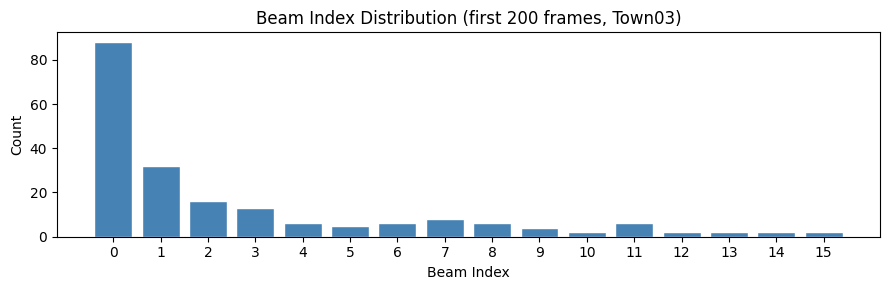

In [ ]:
# ── Sample-level label distribution across N frames ──────────────────
N_SAMPLE = 200   # how many .npz files to scan for quick stats

beam_list = []
with zipfile.ZipFile(CHANNEL_ZIP, "r") as z:
    npz_files_scan = [f for f in z.namelist() if f.endswith("_paths.npz")][:N_SAMPLE]
    for fname in npz_files_scan:
        raw = z.read(fname)
        npz_s = np.load(io.BytesIO(raw))
        a_s = np.squeeze(npz_s["a"])
        if a_s.ndim == 2:
            a_s = a_s[:, :, np.newaxis]
        tx_p = np.sum(np.abs(a_s) ** 2, axis=(0, 2))
        beam_list.append(int(np.argmax(tx_p)))

beam_arr = np.array(beam_list)
counts = np.bincount(beam_arr, minlength=16)
print(f"Beam distribution over {len(beam_arr)} frames:")
for i, c in enumerate(counts):
    bar = "█" * int(c / max(counts) * 30)
    print(f"  Beam {i:2d} | {c:4d} | {bar}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(16), counts, color="steelblue", edgecolor="white")
ax.set_xlabel("Beam Index")
ax.set_ylabel("Count")
ax.set_title(f"Beam Index Distribution (first {len(beam_arr)} frames, Town03)")
ax.set_xticks(range(16))
plt.tight_layout()
plt.show()


## 1. Imports & Reproducibility

In [ ]:
import numpy as np
import random
import os
import re
import io
import zipfile
import pickle
import hashlib
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path, PurePosixPath
from typing import Dict, List, Optional, Sequence, Tuple, Union

import flwr as fl
import ray
import tensorflow as tf
from tensorflow import keras
import pandas as pd

# ── Reproducibility ───────────────────────────────────────────────────
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(seed)
tf.keras.backend.clear_session()

results_dir = "experiment_results"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Random seeds set. TF version:", tf.__version__)

Random seeds set. TF version: 2.18.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Configuration

In [ ]:
CFG = {
    # Training
    "local_epochs"   : 3,        # 1 epoch/round prevents client drift in FedAvg
    "lr"             : 1e-4,     # slower local updates → stabler global convergence
    "batch_size"     : 64,       # Mini-batch size (needed for 800-1300 samples/client)
    "grad_clip_norm" : 5.0,

    # Federated
    "client_frac"    : 0.9,      # Fit/evaluate ALL clients each round

    # Codebook
    # Paper uses Nt=64, Q=64. Our dataset has Nt=16, so Q_tx=16 avoids aliasing.
    # With Nt=16 and Q=64, multiple DFT beams are indistinguishable → mode collapse.
    "Q_tx"           : 16,   # Tx DFT beams = Nt (no oversampling)
    "Q_rx"           : 16,   # Rx DFT beams = Nr

    # Loss fixes for imbalanced binary heads and beam mode collapse
    "pos_weight_los"    : 10.0,  # was 4.5 — 84% NLOS imbalance needs stronger correction
    "pos_weight_change" : 10.0,  # was 5.0 — FedAvg averaging dilutes pos_weight signal
    "label_smoothing"   : 0.15,  # was 0.1 — stronger beam diversity pressure
}

# ── Dynamic client control ────────────────────────────────────────────────────
# Set to an int (e.g. MAX_CLIENTS = 10) to limit the number of client
# trajectories used in both the channel-only and multimodal FL runs.
# This also limits how much data is preloaded during multimodal training,
# making quick experiments much faster.
# Set to None to use all available trajectories.
MAX_CLIENTS = None
print(f'CFG: {CFG}')
print(f'MAX_CLIENTS: {MAX_CLIENTS}  (None = use all)')


CFG: {'local_epochs': 3, 'lr': 0.001, 'batch_size': 64, 'grad_clip_norm': 5.0, 'client_frac': 0.8, 'Q_tx': 16, 'Q_rx': 16, 'pos_weight_los': 10.0, 'pos_weight_change': 10.0, 'label_smoothing': 0.15}
MAX_CLIENTS: None  (None = use all)


## 3. Dataset

In [ ]:
def _parse_total_antennas(config_name: str, side: str) -> int:
    m = re.search(rf"{side}_(\d+)_(\d+)", config_name)
    if not m:
        raise ValueError(f"Could not parse {side} from: {config_name}")
    return int(m.group(1)) * int(m.group(2))


def _safe_isfinite(x: np.ndarray) -> bool:
    if np.iscomplexobj(x):
        return np.isfinite(x.real).all() and np.isfinite(x.imag).all()
    return np.isfinite(x).all()


@dataclass(frozen=True)
class ChannelSampleRef:
    zip_path: Path
    inner_npz: str


def generate_dft_codebook(size: int, num_beams: int) -> np.ndarray:
    """
    DFT steering-vector codebook  (MMW paper Eq. 2 / Eq. 4).

    f(q)[n] = (1 / sqrt(Nt)) * exp(j * 2*pi / Q * n * q)

    Parameters
    ----------
    size      : Nt  – number of Tx antennas
    num_beams : Q   – number of DFT beams (paper uses Q=64)

    Returns
    -------
    codebook : complex64 array of shape (size, num_beams)
               Column q is the steering vector for beam q.
    """
    n = np.arange(size).reshape(-1, 1)
    q = np.arange(num_beams).reshape(1, -1)
    codebook = (1.0 / np.sqrt(size)) * np.exp(
        1j * (2 * np.pi / num_beams) * n * q
    )
    return codebook.astype(np.complex64)


# Sensor frame constants
# LiDAR reduced 512→128 pts: 4× lower RAM; sufficient for A2G spatial coverage.
_N_LIDAR_PTS = 128
_IMU_DIM     = 7   # acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, compass

print("Dataset helpers defined.")
print(f"Sensor constants: _N_LIDAR_PTS={_N_LIDAR_PTS}, _IMU_DIM={_IMU_DIM}")

Dataset helpers defined.
Sensor constants: _N_LIDAR_PTS=128, _IMU_DIM=7


In [ ]:
# Cell: ChannelDataset class (multi-weather, multi-town, all CAVs)
class ChannelDataset:
    """
    Channel-only dataset aligned with MMW paper methodology.
    Supports loading from MULTIPLE weather conditions and towns.

    Feature: Effective channel H = sum_paths(a), shape (Nr, Nt)
             stacked as [real(H), imag(H), |H|]  -> (Nr, Nt, 3)

    Labels (multi-task):
        beam_index : int   — argmax exhaustive beam search (paper Eq. 4)
        g_opt      : float — peak achievable beamforming gain (channel quality)
        los        : int   — 1 = LoS, 0 = NLoS (from NPZ or power-ratio heuristic)
        H_complex  : complex64 (Nr, Nt)
    """

    # Known path variants for different weather conditions
    CHANNEL_PATH_VARIANTS = [
        "Channel Data/V2I",   # sunny layout
        "Channel Data",       # foggy layout (no V2I subdirectory)
    ]

    def __init__(
        self,
        root: Union[str, Path],
        config_name: str,
        Q_tx: int = 16,
        Q_rx: int = 16,
        weather_conditions: Optional[Sequence[str]] = None,
        towns: Optional[Sequence[str]] = None,
        scenario_contains: Optional[str] = None,
        cav_contains: Optional[str] = None,
        stride: int = 1,
        assert_no_nans: bool = True,
        assert_shapes: bool = True,
    ):
        self.root = Path(root)
        self.config_name = config_name

        if weather_conditions is None:
            weather_conditions = ["sunny"]
        self.weather_conditions = list(weather_conditions)

        self.config_dirs = []
        for weather in self.weather_conditions:
            found = False
            for variant in self.CHANNEL_PATH_VARIANTS:
                cdir = self.root / weather / variant / config_name
                if cdir.exists():
                    self.config_dirs.append(cdir)
                    print(f"  [OK] Found channel data: {weather} → {cdir}")
                    found = True
                    break
            if not found:
                print(f"  [WARN] No channel data for '{weather}' — skipped")
        if not self.config_dirs:
            raise FileNotFoundError(
                f"No channel data found for any weather condition: {self.weather_conditions}"
            )

        self.nt = _parse_total_antennas(config_name, "Nt")
        self.nr = _parse_total_antennas(config_name, "Nr")
        self.Q_tx = Q_tx
        self.Q_rx = Q_rx

        self.towns = list(towns) if towns else None
        self.scenario_contains = scenario_contains
        self.cav_contains = cav_contains
        self.stride = max(1, int(stride))
        self.assert_no_nans = assert_no_nans
        self.assert_shapes = assert_shapes

        # DFT codebooks (paper Eq. 2)
        self.tx_codebook = generate_dft_codebook(self.nt, Q_tx)  # (Nt, Q_tx)
        self.rx_codebook = generate_dft_codebook(self.nr, Q_rx)  # (Nr, Q_rx)

        self.index: List[ChannelSampleRef] = self._build_index()
        if self.stride > 1:
            self.index = self.index[::self.stride]

        self._expected_csi_shape: Optional[Tuple[int, ...]] = None

    # -- Index building -------------------------------------------------------
    def _build_index(self) -> List[ChannelSampleRef]:
        refs: List[ChannelSampleRef] = []

        for config_dir in self.config_dirs:
            if self.towns is None:
                zips = sorted(config_dir.glob("Town*.zip"))
                flat_towns = sorted([p.name for p in config_dir.glob("Town*") if p.is_dir()])
            else:
                zips = [config_dir / f"{t}.zip" for t in self.towns]
                flat_towns = list(self.towns)

            seen_towns = set()

            for zp in zips:
                town = zp.stem
                seen_towns.add(town)
                flat_dir = zp.with_suffix("")   # Town03/ next to Town03.zip

                if flat_dir.exists() and any(flat_dir.rglob("*_paths.npz")):
                    # Fast path: scan flat directory — no ZIP open needed
                    for p_flat in sorted(flat_dir.rglob("*_paths.npz")):
                        name = str(PurePosixPath(p_flat.relative_to(flat_dir)))
                        if self.scenario_contains and self.scenario_contains.lower() not in name.lower():
                            continue
                        if self.cav_contains and self.cav_contains.lower() not in name.lower():
                            continue
                        refs.append(ChannelSampleRef(zip_path=zp, inner_npz=name))
                elif zp.exists():
                    # Fallback: list ZIP contents (Drive FUSE — slow)
                    with zipfile.ZipFile(zp, "r") as z:
                        for name in z.namelist():
                            if not name.endswith("_paths.npz"):
                                continue
                            p = PurePosixPath(name)
                            if self.scenario_contains and self.scenario_contains.lower() not in str(p).lower():
                                continue
                            if self.cav_contains and self.cav_contains.lower() not in str(p).lower():
                                continue
                            refs.append(ChannelSampleRef(zip_path=zp, inner_npz=name))

            # Flat-only fallback: no ZIP present, but TownXX/ exists with extracted npz files.
            for town in flat_towns:
                if town in seen_towns:
                    continue
                flat_dir = config_dir / town
                if not flat_dir.exists() or not any(flat_dir.rglob("*_paths.npz")):
                    continue
                zp = config_dir / f"{town}.zip"  # synthetic path for metadata + flat resolution
                for p_flat in sorted(flat_dir.rglob("*_paths.npz")):
                    name = str(PurePosixPath(p_flat.relative_to(flat_dir)))
                    if self.scenario_contains and self.scenario_contains.lower() not in name.lower():
                        continue
                    if self.cav_contains and self.cav_contains.lower() not in name.lower():
                        continue
                    refs.append(ChannelSampleRef(zip_path=zp, inner_npz=name))

        def sort_key(ref: ChannelSampleRef):
            p = PurePosixPath(ref.inner_npz)
            m = re.match(r"(\d+)_paths$", p.stem)
            return (str(ref.zip_path), str(p.parent), int(m.group(1)) if m else -1)

        refs.sort(key=sort_key)
        if not refs:
            raise ValueError(
                f"No *_paths.npz found under config dirs: {self.config_dirs}"
            )
        return refs

    # -- Metadata --------------------------------------------------------------
    def _parse_metadata(self, inner_path: str) -> Dict[str, str]:
        p = PurePosixPath(inner_path)
        m = re.match(r"(\d+)_paths\.npz$", p.name)
        frame_id = int(m.group(1)) if m else -1
        cav_id = p.parent.name if "cav" in p.parent.name.lower() else "unknown"
        location = p.parent.parent.name or "unknown"
        return {"location": location, "cav_id": cav_id, "frame_id": frame_id}

    def get_sample_metadata(self, idx: int) -> Dict[str, str]:
        ref = self.index[idx]
        meta = self._parse_metadata(ref.inner_npz)
        meta["town"] = ref.zip_path.stem
        meta["zip_path"] = str(ref.zip_path)
        meta["inner_path"] = ref.inner_npz
        for weather in self.weather_conditions:
            if weather in str(ref.zip_path):
                meta["weather"] = weather
                break
        else:
            meta["weather"] = "unknown"
        return meta

    def build_metadata_index(self) -> pd.DataFrame:
        rows = []
        for idx in range(len(self)):
            meta = self.get_sample_metadata(idx)
            meta["sample_idx"] = idx
            rows.append(meta)
        return pd.DataFrame(rows)

    # -- Core loading ----------------------------------------------------------
    def __len__(self) -> int:
        return len(self.index)

    def _load_npz(self, ref: ChannelSampleRef) -> Dict[str, np.ndarray]:
        # Priority 1: SSD cache (fastest — local disk, no FUSE latency)
        if getattr(self, "ssd_root", None):
            try:
                rel = ref.zip_path.with_suffix("").relative_to(self.root)
                ssd_path = Path(self.ssd_root) / rel / ref.inner_npz
                if ssd_path.exists():
                    npz = np.load(ssd_path)
                    return {k: npz[k] for k in npz.files}
            except (ValueError, Exception):
                pass
        # Priority 2: flat .npz next to ZIP on Drive (no ZIP overhead)
        flat_path = ref.zip_path.with_suffix("") / ref.inner_npz
        if flat_path.exists():
            try:
                npz = np.load(flat_path)
                return {k: npz[k] for k in npz.files}
            except (EOFError, Exception):
                pass  # corrupted flat file — fall through to ZIP
        # Priority 3: read from ZIP (original fallback)
        try:
            with zipfile.ZipFile(ref.zip_path, "r") as z:
                raw = z.read(ref.inner_npz)
            npz = np.load(io.BytesIO(raw))
            return {k: npz[k] for k in npz.files}
        except (EOFError, Exception) as e:
            raise EOFError(f"Corrupted npz: {ref.zip_path}/{ref.inner_npz}") from e

    def _extract_csi(self, arrays: Dict[str, np.ndarray]) -> np.ndarray:
        """
        Effective channel matrix as model input.
        Returns (Nr, Nt, 3) float32: [real(H), imag(H), |H|]
        """
        a = arrays["a"]
        if self.assert_no_nans:
            assert _safe_isfinite(a), "Non-finite values in 'a'"

        a_sq = np.squeeze(a).astype(np.complex64)
        if a_sq.ndim == 2:
            a_sq = a_sq[:, :, np.newaxis]
        if a_sq.ndim != 3:
            raise ValueError(f"Unexpected squeezed 'a' shape: {a_sq.shape}")

        H = np.sum(a_sq, axis=2)  # (Nr, Nt) complex64
        csi = np.stack([H.real, H.imag, np.abs(H)], axis=-1).astype(np.float32)

        if self.assert_no_nans:
            assert _safe_isfinite(csi), "Non-finite in csi"
        return csi

    def compute_beam_index(self, a_sq: np.ndarray) -> Tuple[int, float, np.ndarray]:
        """
        Exhaustive beam search (paper Eq. 4).
        Returns (beam_idx, g_opt, H) where g_opt = peak achievable gain.
        """
        H = np.sum(a_sq.astype(np.complex64), axis=2)  # (Nr, Nt)
        response = self.rx_codebook.conj().T @ H @ self.tx_codebook  # (Q_rx, Q_tx)
        gain_per_tx = np.max(np.abs(response) ** 2, axis=0)  # (Q_tx,)
        g_opt = float(gain_per_tx.max())
        return int(np.argmax(gain_per_tx)), g_opt, H

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        for attempt in range(len(self.index)):
            _idx = (idx + attempt) % len(self.index)
            ref = self.index[_idx]
            try:
                arrays = self._load_npz(ref)
            except EOFError:
                if attempt == 0:
                    import warnings
                    warnings.warn(f"[ChannelDataset] Skipping corrupted file: {ref.inner_npz}")
                continue

            a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
            if a_sq.ndim == 2:
                a_sq = a_sq[:, :, np.newaxis]

            csi_tensor = self._extract_csi(arrays)

            if self.assert_shapes:
                if self._expected_csi_shape is None:
                    self._expected_csi_shape = tuple(csi_tensor.shape)
                else:
                    assert tuple(csi_tensor.shape) == self._expected_csi_shape, (
                        f"CSI shape mismatch: {self._expected_csi_shape} vs {csi_tensor.shape}"
                    )

            beam_idx, g_opt, H = self.compute_beam_index(a_sq)

            # LoS: read from NPZ if present; else estimate from dominant-path power ratio
            _los_raw = arrays.get("los", None)
            if _los_raw is not None:
                los = int(np.squeeze(_los_raw).flat[0])
            else:
                path_power  = np.sum(np.abs(a_sq) ** 2, axis=(0, 1))
                total_power = path_power.sum() + 1e-12
                los = 1 if (path_power.max() / total_power) > 0.85 else 0

            labels = {
                "beam_index": np.array(beam_idx, dtype=np.int64),
                "g_opt"     : np.array(g_opt,     dtype=np.float32),
                "los"       : np.array(los,        dtype=np.int32),
                "H_complex" : H,
            }

            return csi_tensor, labels

        raise RuntimeError(f"No valid samples found in dataset (all {len(self.index)} files corrupted?)")


In [ ]:
# ── SensorIndex + load_sensor_frame + MultimodalChannelDataset ────────────────
# Modalities: CSI + LiDAR-512 + IMU  (RGB and GPS dropped)
import yaml
import struct

# ---------------------------------------------------------------------------
#  SensorIndex — discovers sensor zips and resolves channel→sensor alignment
# ---------------------------------------------------------------------------

SENSOR_PATH_VARIANTS = [
    "Sensor Data",
]

@dataclass
class SensorZipEntry:
    """One sensor .zip  (e.g. Town03_Tjunction_wiz_slope_seed42.zip)."""
    zip_path: Path
    scenario_prefix: str        # e.g. "Town03_Tjunction_wiz_slope_seed42"
    channel_location: str       # e.g. "Town03_Tjunction"  (prefix match)
    town: str                   # e.g. "Town03"
    is_zip: bool = True


class SensorIndex:
    """
    Maps  (weather, channel_inner_npz)  →  (SensorZipEntry, cav_id, frame_id)
    so that MultimodalChannelDataset can look up the sensor zip for every
    channel sample.
    """

    def __init__(self, root: Union[str, Path],
                 weather_conditions: Sequence[str],
                 towns: Sequence[str]):
        self.root = Path(root)
        # key = (weather, channel_location, town)  →  SensorZipEntry
        self._map: Dict[Tuple[str, str, str], SensorZipEntry] = {}
        self._build(weather_conditions, towns)

    # ── build ----------------------------------------------------------------
    def _build(self, weathers, towns):
        for weather in weathers:
            for variant in SENSOR_PATH_VARIANTS:
                for town in towns:
                    sensor_dir = self.root / weather / variant / town
                    if not sensor_dir.exists():
                        continue
                    # 2) Flat-extracted scenario directories
                    for d in sorted([p for p in sensor_dir.iterdir() if p.is_dir()]):
                        stem = d.name
                        ch_loc = self._stem_to_channel_location(stem, town)
                        entry = SensorZipEntry(
                            zip_path=d,
                            scenario_prefix=stem,
                            channel_location=ch_loc,
                            town=town,
                            is_zip=False,
                        )
                        key = (weather, ch_loc, town)
                        # Do not overwrite an existing ZIP entry; prefer ZIP when both exist.
                        self._map[key] = entry   # flat always wins
                    # 2) ZIP archives
                    for zp in sorted(sensor_dir.glob("*.zip")):
                        stem = zp.stem  # e.g. Town03_Tjunction_wiz_slope_seed42
                        # derive the channel_location by stripping everything
                        # after the town-specific location tag.
                        # Channel uses e.g. "Town03_Tjunction"
                        # Sensor zip is    "Town03_Tjunction_wiz_slope_seed42"
                        ch_loc = self._stem_to_channel_location(stem, town)
                        entry = SensorZipEntry(
                            zip_path=zp,
                            scenario_prefix=stem,
                            channel_location=ch_loc,
                            town=town,
                            is_zip=True,
                        )
                        key = (weather, ch_loc, town)
                        self._map.setdefault(key, entry)

        n = len(self._map)
        n_zip = sum(1 for v in self._map.values() if v.is_zip)
        n_flat = n - n_zip
        print(f"[SensorIndex] {n} sensor sources indexed ({n_zip} zip + {n_flat} flat)")

    @staticmethod
    def _stem_to_channel_location(stem: str, town: str) -> str:
        """
        Town03_Tjunction_wiz_slope_seed42  →  Town03_Tjunction
        Town03_5wayroad_seed28             →  Town03_5wayroad
        Heuristic: the channel location = town + '_' + next word.
        """
        # Remove the town prefix to isolate the location part
        rest = stem[len(town) + 1:]  # "Tjunction_wiz_slope_seed42"
        # Take everything up to the first _seed or _wiz or similar suffix
        # Strategy: split on '_' and take parts until we hit a known suffix
        parts = rest.split("_")
        loc_parts = []
        stop_words = {"wiz", "seed", "slope"}
        for p in parts:
            if p.lower() in stop_words or re.match(r"seed\d+", p.lower()):
                break
            loc_parts.append(p)
        location = "_".join(loc_parts)  # "Tjunction" or "5wayroad" etc.
        return f"{town}_{location}"

    # ── resolve ---------------------------------------------------------------
    def resolve(self, weather: str, channel_inner_npz: str):
        """
        Given a channel inner path like
            Town03/Town03_Tjunction/cav_1/004276_paths.npz
        return (SensorZipEntry, cav_id, frame_id) or None.
        """
        p = PurePosixPath(channel_inner_npz)
        # parts: ('Town03', 'Town03_Tjunction', 'cav_1', '004276_paths.npz')
        if len(p.parts) < 4:
            return None
        town = p.parts[0]
        ch_location = p.parts[1]
        cav_id = p.parts[2]
        m = re.match(r"(\d+)_paths\.npz$", p.parts[3])
        if not m:
            return None
        frame_id = m.group(1)   # string like "004276"

        key = (weather, ch_location, town)
        entry = self._map.get(key)
        if entry is None:
            return None
        return (entry, cav_id, frame_id)


# ---------------------------------------------------------------------------
#  load_sensor_frame — reads LiDAR + IMU from a sensor zip
# ---------------------------------------------------------------------------

def _read_pcd_xyz(raw_bytes: bytes) -> np.ndarray:
    """Parse ASCII PCD → (N, 3) float32 (only xyz, ignore rgb)."""
    lines = raw_bytes.split(b"\n")
    header_end = 0
    n_points = 0
    for i, line in enumerate(lines):
        text = line.decode(errors="replace").strip()
        if text.startswith("POINTS"):
            n_points = int(text.split()[1])
        if text == "DATA ascii":
            header_end = i + 1
            break
    pts = []
    for line in lines[header_end: header_end + n_points]:
        parts = line.split()
        if len(parts) >= 3:
            pts.append([float(parts[0]), float(parts[1]), float(parts[2])])
    return np.array(pts, dtype=np.float32) if pts else np.zeros((0, 3), np.float32)


def load_sensor_frame(
    entry: SensorZipEntry,
    cav_id: str,
    frame_id: str,
    n_lidar_pts: int = _N_LIDAR_PTS,
    rng: np.random.Generator = None,
) -> Dict[str, np.ndarray]:
    """
    Load LiDAR and IMU from sensor data source (ZIP or flat folder).

    Sensor zip layout:
        <scenario>/<cav_id>/<frame_id>.pcd   → LiDAR point cloud
        <scenario>/<cav_id>/<frame_id>.yaml  → IMU (imu_measurement section)

    Returns
    -------
    {"lidar": (n_lidar_pts, 3) float32, "imu": (7,) float32}
    IMU layout: [acc_x/g, acc_y/g, acc_z/g, gyro_x, gyro_y, gyro_z, compass/360]
    """
    if rng is None:
        rng = np.random.default_rng(42)

    prefix = f"{entry.scenario_prefix}/{cav_id}/{frame_id}"

    if entry.is_zip:
        with zipfile.ZipFile(entry.zip_path, "r") as z:
            pcd_raw = z.read(f"{prefix}.pcd")
            yaml_raw = z.read(f"{prefix}.yaml")
    else:
        # Flat layout can be either:
        #   <scenario>/<cav>/<frame>.pcd  or  <scenario>/<scenario>/<cav>/<frame>.pcd
        p = Path(entry.zip_path)
        cand1 = p / cav_id / f"{frame_id}.pcd"
        cand2 = p / entry.scenario_prefix / cav_id / f"{frame_id}.pcd"
        pcd_path = cand1 if cand1.exists() else cand2

        y1 = p / cav_id / f"{frame_id}.yaml"
        y2 = p / entry.scenario_prefix / cav_id / f"{frame_id}.yaml"
        yaml_path = y1 if y1.exists() else y2

        pcd_raw = pcd_path.read_bytes()
        yaml_raw = yaml_path.read_bytes()

    # ── LiDAR ─────────────────────────────────────────────────────────────
    pts = _read_pcd_xyz(pcd_raw)
    if len(pts) == 0:
        pts = np.zeros((1, 3), np.float32)
    if len(pts) >= n_lidar_pts:
        idx = rng.choice(len(pts), n_lidar_pts, replace=False)
        pts = pts[idx]
    else:
        pad = np.zeros((n_lidar_pts - len(pts), 3), np.float32)
        pts = np.concatenate([pts, pad], axis=0)
    mean = pts.mean(axis=0, keepdims=True)
    std  = pts.std(axis=0, keepdims=True) + 1e-8
    lidar = ((pts - mean) / std).astype(np.float32)

    # ── IMU (from YAML) ───────────────────────────────────────────────────
    meta = yaml.safe_load(yaml_raw)
    imu_meta = meta["sensors"]["imu_measurement"]
    if imu_meta.get("data_missing", False):
        imu = np.zeros(_IMU_DIM, np.float32)
    else:
        acc  = imu_meta["accelerometer"]
        gyro = imu_meta["gyroscope"]
        comp = float(imu_meta.get("compass", 0.0))
        imu  = np.array([
            acc["x"]  / 9.81,  acc["y"]  / 9.81,  acc["z"]  / 9.81,
            gyro["x"],         gyro["y"],          gyro["z"],
            comp / 360.0,
        ], dtype=np.float32)

    return {"lidar": lidar, "imu": imu}


# ---------------------------------------------------------------------------
#  MultimodalChannelDataset
# ---------------------------------------------------------------------------
class MultimodalChannelDataset:
    """
    Aligns channel samples with their sensor observations.

    __getitem__ returns:
        csi    : (Nr, Nt, 3)          float32
        lidar  : (_N_LIDAR_PTS, 3)    float32  normalised xyz  (512 pts)
        imu    : (_IMU_DIM,)          float32  [acc/g ×3, gyro ×3, compass/360]
        labels : {"beam_index": int64, "H_complex": complex64 (Nr,Nt)}
    """

    def __init__(
        self,
        channel_dataset: "ChannelDataset",
        sensor_index: SensorIndex,
        n_lidar_pts: int = _N_LIDAR_PTS,
        seed: int = 42,
    ):
        self.channel_ds  = channel_dataset
        self.sensor_idx  = sensor_index
        self.n_lidar_pts = n_lidar_pts
        self._rng        = np.random.default_rng(seed)

        self._sensor_map = self._build_sensor_map()
        matched = sum(1 for v in self._sensor_map if v is not None)
        print(f"[MultimodalDataset] {len(self)} samples  |"
              f"  sensor-aligned: {matched}  |"
              f"  fallback (zeros): {len(self) - matched}")

    def _build_sensor_map(self):
        mapping = []
        for idx in range(len(self.channel_ds)):
            ref  = self.channel_ds.index[idx]
            meta = self.channel_ds.get_sample_metadata(idx)
            weather = meta.get("weather", "sunny")
            resolved = self.sensor_idx.resolve(weather, ref.inner_npz)
            mapping.append(resolved)
        return mapping

    def __len__(self):
        return len(self.channel_ds)

    def __getitem__(self, idx: int):
        csi, labels = self.channel_ds[idx]

        resolved = self._sensor_map[idx]
        if resolved is not None:
            entry, cav_id, frame_id = resolved
            try:
                sensor = load_sensor_frame(
                    entry, cav_id, frame_id,
                    n_lidar_pts=self.n_lidar_pts,
                    rng=self._rng,
                )
                lidar = sensor["lidar"]
                imu   = sensor["imu"]
            except Exception:
                lidar, imu = self._zeros()
        else:
            lidar, imu = self._zeros()

        return csi, lidar, imu, labels

    def _zeros(self):
        lidar = np.zeros((self.n_lidar_pts, 3), np.float32)
        imu   = np.zeros(_IMU_DIM, np.float32)
        return lidar, imu

    @property
    def tx_codebook(self): return self.channel_ds.tx_codebook
    @property
    def rx_codebook(self): return self.channel_ds.rx_codebook
    @property
    def nr(self): return self.channel_ds.nr
    @property
    def nt(self): return self.channel_ds.nt


print("SensorIndex, load_sensor_frame, MultimodalChannelDataset defined.")

SensorIndex, load_sensor_frame, MultimodalChannelDataset defined.


In [ ]:
# -- Methodology Sanity Check --------------------------------------------------
# Verify DFT codebooks, beam selection, and normalized gain.
import numpy as np

Q_tx, Q_rx, Nt, Nr = 64, 16, 16, 16

# 1. Codebooks
tx_cb = generate_dft_codebook(Nt, Q_tx)  # (16, 64)
rx_cb = generate_dft_codebook(Nr, Q_rx)  # (16, 16)
assert tx_cb.shape == (Nt, Q_tx)
assert rx_cb.shape == (Nr, Q_rx)

# Rx codebook is square DFT -> should be unitary
gram_rx = rx_cb.conj().T @ rx_cb
assert np.allclose(gram_rx, np.eye(Q_rx), atol=1e-4), "Rx codebook not unitary"
print(f"Tx codebook: {tx_cb.shape} (Nt={Nt}, Q_tx={Q_tx})")
print(f"Rx codebook: {rx_cb.shape} (Nr={Nr}, Q_rx={Q_rx}, unitary)")

# 2. Simulate exhaustive beam search (Eq. 4)
rng = np.random.default_rng(42)
n_paths = 8
a_fake = (rng.standard_normal((Nr, Nt, n_paths))
        + 1j * rng.standard_normal((Nr, Nt, n_paths))).astype(np.complex64)
H = np.sum(a_fake, axis=2)  # (Nr, Nt)

response = rx_cb.conj().T @ H @ tx_cb  # (Q_rx, Q_tx)
gain_per_tx = np.max(np.abs(response)**2, axis=0)
beam_idx = int(np.argmax(gain_per_tx))
assert 0 <= beam_idx < Q_tx
print(f"Beam index: {beam_idx} (range 0-{Q_tx-1})")

# 3. Normalized gain (Eq. 3)
optimal_gain = np.max(np.abs(response)**2)
achieved_gain = gain_per_tx[beam_idx]
norm_gain = achieved_gain / (optimal_gain + 1e-12)
print(f"Normalized gain: {norm_gain:.4f} (should be 1.0 for optimal)")
assert np.isclose(norm_gain, 1.0), "Optimal selection should give gain=1.0"

# 4. Feature tensor shape (with geometric features)
# Simulate geometric features
tau_mean = 1e-7
theta_mean = np.pi/2
phi_mean = np.pi/4
tau_grid = np.full((Nr, Nt), tau_mean, dtype=np.float32)
theta_grid = np.full((Nr, Nt), theta_mean, dtype=np.float32)
phi_grid = np.full((Nr, Nt), phi_mean, dtype=np.float32)

csi = np.stack([H.real, H.imag, np.abs(H), tau_grid, theta_grid, phi_grid], axis=-1).astype(np.float32)
assert csi.shape == (Nr, Nt, 6)
print(f"CSI feature shape: {csi.shape}  [real(H), imag(H), |H|, tau, theta_t, phi_t]")

print("\nAll checks passed.")


Tx codebook: (16, 64) (Nt=16, Q_tx=64)
Rx codebook: (16, 16) (Nr=16, Q_rx=16, unitary)
Beam index: 23 (range 0-63)
Normalized gain: 1.0000 (should be 1.0 for optimal)
CSI feature shape: (16, 16, 6)  [real(H), imag(H), |H|, tau, theta_t, phi_t]

All checks passed.


In [ ]:
class DatasetSplitter:
    """Trajectory-aware train/test splitting (1 client = 1 CAV trajectory)."""

    def __init__(self, dataset: ChannelDataset):
        self.dataset = dataset
        self.metadata_df = dataset.build_metadata_index()
        print(f"Metadata index built: {len(self.metadata_df)} samples")
        # Summary stats
        n_towns = self.metadata_df["town"].nunique()
        n_weather = self.metadata_df["weather"].nunique() if "weather" in self.metadata_df.columns else 1
        print(f"  Towns: {n_towns}, Weather conditions: {n_weather}")

    def get_trajectory_groups(self) -> Dict[str, List[int]]:
        trajectories = {}
        # Group by weather + town + location + cav for unique trajectories
        group_cols = ["town", "location", "cav_id"]
        if "weather" in self.metadata_df.columns:
            group_cols = ["weather"] + group_cols

        for keys, group in self.metadata_df.groupby(group_cols):
            if isinstance(keys, tuple):
                traj_id = "_".join(str(k) for k in keys)
            else:
                traj_id = str(keys)
            trajectories[traj_id] = group.sort_values("frame_id")["sample_idx"].tolist()
        return trajectories

    def split_trajectory_temporal(
        self, indices: List[int], train_ratio: float = 0.7
    ) -> Tuple[List[int], List[int]]:
        """
        Temporal split: first 70% → train, last 30% → test.
        Tests generalization to new positions along trajectory.
        """
        split = int(len(indices) * train_ratio)
        return indices[:split], indices[split:]

    def split_trajectory_random(
        self, indices: List[int], train_ratio: float = 0.7, seed: int = 42
    ) -> Tuple[List[int], List[int]]:
        """
        Random split: shuffle then split 70/30.
        Tests generalization to unseen samples from SAME distribution.
        """
        rng = np.random.RandomState(seed)
        shuffled = np.array(indices.copy())
        rng.shuffle(shuffled)
        split = int(len(shuffled) * train_ratio)
        return shuffled[:split].tolist(), shuffled[split:].tolist()


@dataclass
class ChannelClientData:
    train_indices: List[int]
    test_indices: List[int]
    client_id: int
    trajectory_id: str


def build_clients(
    dataset: ChannelDataset,
    train_ratio: float = 0.7,
    min_trajectory_length: int = 10,
    split_strategy: str = "temporal",  # "temporal" or "random"
) -> Tuple[List[ChannelClientData], Dict[str, List[int]]]:
    """
    Build federated clients from trajectory data.

    Returns
    -------
    clients      : list of ChannelClientData (one per trajectory)
    trajectories : the full trajectory dict — reuse in precompute_beam_changes
                   to avoid rebuilding DatasetSplitter a second time.

    Args:
        split_strategy:
            - "temporal": first 70% train, last 30% test
            - "random"  : random 70/30 split
    """
    splitter = DatasetSplitter(dataset)
    trajectories = splitter.get_trajectory_groups()
    print(f"Total trajectories: {len(trajectories)}")

    trajectories = {
        t: idx for t, idx in trajectories.items() if len(idx) >= min_trajectory_length
    }
    print(f"After length filter (>={min_trajectory_length}): {len(trajectories)}")

    clients = []
    for cid, traj_id in enumerate(sorted(trajectories)):
        if split_strategy == "random":
            train_idx, test_idx = splitter.split_trajectory_random(
                trajectories[traj_id], train_ratio
            )
        else:  # temporal
            train_idx, test_idx = splitter.split_trajectory_temporal(
                trajectories[traj_id], train_ratio
            )
        if not train_idx or not test_idx:
            continue
        clients.append(
            ChannelClientData(train_idx, test_idx, cid, traj_id)
        )

    total_train = sum(len(c.train_indices) for c in clients)
    total_test = sum(len(c.test_indices) for c in clients)
    print(f"\nClients created: {len(clients)} (split_strategy={split_strategy})")
    print(f"Total train samples: {total_train}")
    print(f"Total test samples:  {total_test}")
    print(f"Avg samples per client: {(total_train + total_test) / max(len(clients), 1):.0f}")
    return clients, trajectories

# ── Hierarchical Cluster Assignment ──────────────────────────────────────────
TOWN_ORDER = ["Town03", "Town05", "Town07", "Town10"]


def _client_sort_key(c: ChannelClientData):
    """Sort key: (town_rank, location, weather, cav_id) from trajectory_id."""
    parts    = c.trajectory_id.split("_")
    weather  = parts[0]
    town     = parts[1]
    location = "_".join(parts[2:-1])
    cav_id   = parts[-1]
    return (TOWN_ORDER.index(town) if town in TOWN_ORDER else 99,
            location, weather, cav_id)


def build_clusters(clients: List[ChannelClientData], n_clusters: int = 3
                   ) -> Dict[int, List[int]]:
    """
    Assign FL clients to n_clusters equal-size geographic clusters for
    hierarchical aggregation (Cluster Head model).

    Clients are sorted by (town_rank, location, weather, cav_id) to produce
    a town-ordered list, then divided into n_clusters equal thirds.
    This guarantees equal cluster sizes regardless of per-town location counts.

    Communication design (3 clusters):
        CH0  — Cluster 0 intra-cluster aggregate         (Town03-heavy)
        CH1  — Cluster 1 intra-cluster aggregate          (Town05/07 boundary)
               + global aggregator: receives from CH0 and CH2
        CH2  — Cluster 2 intra-cluster aggregate         (Town10-heavy)

    Returns
    -------
    cluster_map : Dict[cluster_id -> List[client_index]]
        client_index = 0-based position in the original `clients` list.
    """
    sorted_indices = sorted(range(len(clients)), key=lambda i: _client_sort_key(clients[i]))
    N      = len(sorted_indices)
    thirds = [N // n_clusters + (1 if i < N % n_clusters else 0)
              for i in range(n_clusters)]

    cluster_map: Dict[int, List[int]] = {}
    start = 0
    for cid, size in enumerate(thirds):
        cluster_map[cid] = sorted_indices[start : start + size]
        start += size

    # Print summary
    for cid, idxs in cluster_map.items():
        towns_in = [clients[i].trajectory_id.split("_")[1] for i in idxs]
        counts   = {t: towns_in.count(t) for t in TOWN_ORDER if t in towns_in}
        print(f"  Cluster {cid} (CH{cid}): {len(idxs)} clients — {counts}")

    return cluster_map


We group by the frames by town, location, cav_id

build trajectories like this

{
  "Town03_TJ_cav1": [0,1,2,...],
  "Town03_TJ_cav2": [...],
}

len(idx) >= min_trajectory_length (set to 10)

Then we assign each trajectory to one client as a CAV

In [ ]:
# ── Cell: Load Dataset ── channel + multimodal + build clients ────────────────
tf.keras.backend.clear_session()

WEATHER_CONDITIONS = ["sunny", "foggy", "rainy"]
TOWNS = ["Town03", "Town05", "Town07", "Town10"]
DATA_ROOT = "/content/drive/MyDrive/Dataset_flat"

# 1. Channel-only dataset
ds = ChannelDataset(
    root=DATA_ROOT,
    config_name="Nt_1_16_Nr_1_16_fc_28GHz",
    weather_conditions=WEATHER_CONDITIONS,
    towns=TOWNS,
    stride=10,
    Q_tx=CFG["Q_tx"],
    Q_rx=CFG["Q_rx"],
)
print(f"\nChannel dataset: {len(ds)} samples  (stride=10, all towns)")
print(f"Config dirs: {len(ds.config_dirs)}")

x, y = ds[0]
print(f"CSI shape   : {x.shape}")
print(f"Beam index  : {y['beam_index']}  g_opt: {y['g_opt']:.4f}  los: {y['los']}")

# 2. Sensor index (for multimodal)
sensor_idx = SensorIndex(
    root=DATA_ROOT,
    weather_conditions=WEATHER_CONDITIONS,
    towns=TOWNS,
)

# 3. Multimodal dataset (wraps channel dataset + sensor index)
mm_ds = MultimodalChannelDataset(
    channel_dataset=ds,
    sensor_index=sensor_idx,
)

# 4. Build federated clients (trajectory-aware)
clients, _trajectories = build_clients(ds, train_ratio=0.7, min_trajectory_length=10, split_strategy="temporal")

# ── Cap number of clients if MAX_CLIENTS is set ───────────────────────────────
if MAX_CLIENTS is not None:
    clients = clients[:MAX_CLIENTS]
    print(f'\n  Capped to {len(clients)} clients (MAX_CLIENTS={MAX_CLIENTS})')

# ── Precompute beam_change labels ─────────────────────────────────────────────
def precompute_beam_changes(
    channel_ds: ChannelDataset,
    clients: list,
    trajectories: dict,
) -> dict:
    from collections import defaultdict
    import json as _json, hashlib as _hl, io as _io, zipfile as _zf
    print("Precomputing beam_change labels (flat-first batch reads; ZIP fallback)...")
    _t = time.time()

    client_idx_set = set()
    for c in clients:
        client_idx_set.update(c.train_indices)
        client_idx_set.update(c.test_indices)

    needed_indices: set = set()
    for traj_id, indices in trajectories.items():
        if client_idx_set.intersection(indices):
            needed_indices.update(indices)

    # Cache saved to Drive so it survives Colab restarts
    _cache_key  = _hl.md5(str(sorted(needed_indices)).encode()).hexdigest()[:10]
    _cache_file = Path(DATA_ROOT) / f"beam_changes_{_cache_key}.json"
    if _cache_file.exists():
        print(f"  [cache hit] {_cache_file.name}")
        data = _json.load(open(_cache_file))
        changes_cached = {int(k): v for k, v in data.items()}
        for i in client_idx_set:
            changes_cached.setdefault(i, 0)
        n_chg = sum(changes_cached.values())
        print(f"  Done in {time.time()-_t:.1f}s (cached) — beam transitions: {n_chg}/{len(changes_cached)}")
        return changes_cached

    zip_groups = defaultdict(list)
    for idx in needed_indices:
        zip_groups[channel_ds.index[idx].zip_path].append(idx)

    beam_cache: dict = {}
    n_zips = len(zip_groups)
    for z_i, (zip_path, idx_list) in enumerate(zip_groups.items(), 1):
        flat_todo, zip_todo = [], []
        for idx in idx_list:
            fp = zip_path.with_suffix("") / channel_ds.index[idx].inner_npz
            (flat_todo if fp.exists() else zip_todo).append((idx, fp))

        # Flat reads — fall back to ZIP on any error (empty/corrupt file)
        zip_fallback = []
        for idx, fp in flat_todo:
            try:
                arrays = np.load(fp)
                a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
                if a_sq.ndim == 2: a_sq = a_sq[:, :, np.newaxis]
                beam_cache[idx], _, _ = channel_ds.compute_beam_index(a_sq)
            except Exception:
                zip_fallback.append((idx, channel_ds.index[idx].inner_npz))

        # ZIP reads (original + fallback from corrupt flat files)
        all_zip_todo = [(idx, channel_ds.index[idx].inner_npz) for idx, _ in zip_todo] + zip_fallback
        if all_zip_todo:
            try:
                with _zf.ZipFile(zip_path, "r") as zf:
                    for idx, inner in all_zip_todo:
                        try:
                            raw = zf.read(inner)
                            arrays = np.load(_io.BytesIO(raw))
                            a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
                            if a_sq.ndim == 2: a_sq = a_sq[:, :, np.newaxis]
                            beam_cache[idx], _, _ = channel_ds.compute_beam_index(a_sq)
                        except Exception:
                            pass  # skip corrupt ZIP entry
            except (FileNotFoundError, _zf.BadZipFile):
                pass

        if zip_fallback:
            print(f"  [warn] {len(zip_fallback)} corrupt flat files fell back to ZIP")
        print(f"  ZIP {z_i}/{n_zips}: {zip_path.name} "
              f"({len(flat_todo)-len(zip_fallback)} flat + {len(all_zip_todo)} zip)")

    changes: dict = {}
    for traj_id, indices in trajectories.items():
        if not client_idx_set.intersection(indices):
            continue
        prev_beam = None
        for idx in indices:
            b = beam_cache.get(idx)
            if b is None:
                prev_beam = None
                continue
            if idx in client_idx_set:
                changes[idx] = 0 if prev_beam is None else int(b != prev_beam)
            prev_beam = b

    for i in client_idx_set:
        changes.setdefault(i, 0)

    n_chg = sum(changes.values())
    print(f"  Done in {time.time()-_t:.1f}s — {len(needed_indices)} frames across {n_zips} ZIPs | "
          f"beam transitions: {n_chg}/{len(changes)} ({100*n_chg/max(len(changes),1):.1f}%)")
    try:
        _json.dump({str(k): v for k, v in changes.items()}, open(_cache_file, "w"))
        print(f"  [cache saved] → {_cache_file.name}")
    except Exception as e:
        print(f"  [cache save failed] {e}")
    return changes

beam_changes_global = precompute_beam_changes(ds, clients, _trajectories)

# Quick label check
sample_n = min(10, len(ds))
beam_labels = [ds[i][1]["beam_index"].item() for i in range(sample_n)]
gopt_labels = [ds[i][1]["g_opt"].item()      for i in range(sample_n)]
los_labels  = [ds[i][1]["los"].item()        for i in range(sample_n)]
print(f"\nLabel summary (first {sample_n} samples):")
print(f"  beam_index : range [{min(beam_labels)}, {max(beam_labels)}]  "
      f"| unique={len(set(beam_labels))}")
print(f"  g_opt      : min={min(gopt_labels):.6f}  max={max(gopt_labels):.6f}")
print(f"  los        : LoS={sum(los_labels)}/{sample_n}  "
      f"({100.0*sum(los_labels)/sample_n:.1f}%)")
print(f"  beam_change: transitions in global dict = {sum(beam_changes_global.values())}")
print(f"\nBeam distribution: {np.bincount(beam_labels, minlength=CFG['Q_tx'])}")

# ── Aliases used by the multimodal FL training cell ───────────────────────────
mm_channel_ds  = ds
mm_clients_raw = clients

  [OK] Found channel data: sunny → /content/drive/MyDrive/Dataset_flat/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz
  [OK] Found channel data: foggy → /content/drive/MyDrive/Dataset_flat/foggy/Channel Data/Nt_1_16_Nr_1_16_fc_28GHz
  [OK] Found channel data: rainy → /content/drive/MyDrive/Dataset_flat/rainy/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz

Channel dataset: 11740 samples  (stride=10, all towns)
Config dirs: 3
CSI shape   : (16, 16, 3)
Beam index  : 8  g_opt: 0.0000  los: 0
[SensorIndex] 48 sensor sources indexed (0 zip + 48 flat)
[MultimodalDataset] 11740 samples  |  sensor-aligned: 11140  |  fallback (zeros): 600
Metadata index built: 11740 samples
  Towns: 4, Weather conditions: 3
Total trajectories: 111
After length filter (>=10): 111

Clients created: 111 (split_strategy=temporal)
Total train samples: 8218
Total test samples:  3522
Avg samples per client: 106
Precomputing beam_change labels (flat-first batch reads; ZIP fallback)...
  [cache hit] beam_changes_d32a2128f4.j

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Done in 0.4s (cached) — beam transitions: 1924/11740

Label summary (first 10 samples):
  beam_index : range [8, 8]  | unique=1
  g_opt      : min=0.000000  max=0.000002
  los        : LoS=1/10  (10.0%)
  beam_change: transitions in global dict = 1924

Beam distribution: [ 0  0  0  0  0  0  0  0 10  0  0  0  0  0  0  0]


## 7. Model Architecture (Beam Only)

Conv(32) = for edges

Conv(64) = for the shapes

Conv(128) = high level learning

BN -> normalize the extremes
Relu -> if it's insignificant, then remove it from the calculation

The Dense layer converts features space and provides insights from the conv layers

In [ ]:
# ── Model Architecture ────────────────────────────────────────────────────────
#  1. ChannelEncoder        — CNN for CSI  (Nr, Nt, 3)
#  2. LiDAREncoder          — PointNet-style for LiDAR  (128, 3) [slimmed]
#  3. IMUEncoder            — GRU over 7 IMU components  (7,) → (7,1) sequence
#  4. CrossModalAttention   — multi-head attention fusion over 3 modalities
#  5. BeamModel             — channel-only multi-task head
#  6. MultimodalBeamModel   — full multimodal multi-task head
#
# Shared helper (avoids duplication across clients):
#   _compute_normalized_gain(H_batch, pred_indices, tx_cb, rx_cb) → float
# ──────────────────────────────────────────────────────────────────────────────

def _compute_normalized_gain(H_batch, pred_indices, tx_codebook, rx_codebook):
    """Mean normalised beamforming gain over a batch. Used by both clients."""
    gains = []
    for i in range(len(pred_indices)):
        H           = H_batch[i]
        resp        = rx_codebook.conj().T @ H @ tx_codebook
        gain_matrix = np.abs(resp) ** 2
        achieved    = np.max(gain_matrix[:, pred_indices[i]])
        optimal     = np.max(gain_matrix)
        gains.append(achieved / (optimal + 1e-12))
    return float(np.mean(gains))


@tf.keras.utils.register_keras_serializable()
class ChannelEncoder(tf.keras.Model):
    """CNN encoder for effective channel matrix. Input: (B, Nr, Nt, 3)."""
    def __init__(self, nr: int, nt: int, emb_dim: int = 128, dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = keras.layers.Conv2D(32,  3, padding="same", activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv2D(64,  3, padding="same", activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.conv3 = keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.bn3   = keras.layers.BatchNormalization()
        self.gap   = keras.layers.GlobalAveragePooling2D()
        self.proj  = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(emb_dim),
        ])

    def call(self, x, training=False):
        h = self.bn1(self.conv1(x), training=training)
        h = self.bn2(self.conv2(h), training=training)
        h = self.bn3(self.conv3(h), training=training)
        h = self.gap(h)
        return self.proj(h, training=training)


@tf.keras.utils.register_keras_serializable()
class LiDAREncoder(tf.keras.Model):
    """
    PointNet-style encoder for LiDAR point clouds.
    Input:  (B, 128, 3)  — xyz points (downsampled from 512)
    Output: (B, emb_dim)
    Channels halved (64→128→256 became 32→64→128) to match reduced point count.
    """
    def __init__(self, emb_dim: int = 128, dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = keras.layers.Conv1D(32,  1, activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv1D(64,  1, activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.conv3 = keras.layers.Conv1D(128, 1, activation="relu")
        self.bn3   = keras.layers.BatchNormalization()
        self.pool  = keras.layers.GlobalMaxPooling1D()
        self.proj  = keras.Sequential([
            keras.layers.Dense(emb_dim, activation="relu"),
            keras.layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        h = self.bn1(self.conv1(x), training=training)
        h = self.bn2(self.conv2(h), training=training)
        h = self.bn3(self.conv3(h), training=training)
        h = self.pool(h)
        return self.proj(h, training=training)


@tf.keras.utils.register_keras_serializable()
class IMUEncoder(tf.keras.Model):
    """
    GRU encoder for IMU vector (acc_xyz + gyro_xyz + compass = 7 values).
    Each IMU component is treated as one timestep of a 1-D sequence, so the
    GRU learns inter-component dependencies (e.g. acc→gyro coupling).
    Input:  (B, 7)  →  reshaped to  (B, 7, 1)
    Output: (B, emb_dim)
    Lightweight: GRU(32) uses ~4× fewer params than the previous Dense(64→128).
    """
    def __init__(self, emb_dim: int = 128, dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.gru  = keras.layers.GRU(32, return_sequences=False)
        self.proj = keras.Sequential([
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(emb_dim),
        ])

    def call(self, x, training=False):
        seq = tf.expand_dims(x, axis=-1)        # (B, 7) → (B, 7, 1)
        h   = self.gru(seq, training=training)  # (B, 32)
        return self.proj(h, training=training)


@tf.keras.utils.register_keras_serializable()
class CrossModalAttention(tf.keras.layers.Layer):
    """
    Multi-head attention over stacked modality embeddings.
    Input:  list of (B, emb_dim) tensors
    Output: (B, emb_dim) — attended fusion
    """
    def __init__(self, emb_dim: int = 128, n_heads: int = 4, **kwargs):
        super().__init__(**kwargs)
        self.mha  = keras.layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=emb_dim // n_heads
        )
        self.norm = keras.layers.LayerNormalization()

    def call(self, embeddings, training=False):
        x        = tf.stack(embeddings, axis=1)      # (B, n_mod, emb_dim)
        attn_out = self.mha(x, x, training=training)
        x        = self.norm(x + attn_out)
        return tf.reduce_mean(x, axis=1)             # (B, emb_dim)


# ──────────────────────────────────────────────────────────────────────────────
# Channel-only multi-task model
# Predicts: beam_index | g_opt | los | beam_change
# ──────────────────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable()
class BeamModel(keras.Model):
    """
    Multi-task beam prediction — channel only.

    Outputs dict:
        'beam'        : (B, n_beams)  beam classification logits
        'gopt'        : (B,)          peak gain, z-score normalised (MSE)
        'los'         : (B,)          LoS/NLoS logit (binary)
        'beam_change' : (B,)          beam-switch logit (binary)
    """
    def __init__(self, nr: int, nt: int, beam_codebook_size: int,
                 dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = ChannelEncoder(nr, nt, emb_dim=128, dropout=dropout)
        self.shared  = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(128, activation="relu"),
        ])
        self.beam_head   = keras.layers.Dense(beam_codebook_size, name="beam")
        self.gopt_head   = keras.layers.Dense(1, name="gopt")
        self.los_head    = keras.layers.Dense(1, name="los")
        self.change_head = keras.layers.Dense(1, name="beam_change")

    def call(self, x, training=False):
        emb = self.encoder(x, training=training)
        h   = self.shared(emb, training=training)
        return {
            "beam"       : self.beam_head(h),
            "gopt"       : tf.squeeze(self.gopt_head(h),   axis=-1),
            "los"        : tf.squeeze(self.los_head(h),    axis=-1),
            "beam_change": tf.squeeze(self.change_head(h), axis=-1),
        }

    def build_model(self, nr, nt):
        _ = self(tf.random.normal((1, nr, nt, 3)), training=False)
        self.built = True


# ──────────────────────────────────────────────────────────────────────────────
# Multimodal multi-task model (CSI + LiDAR-128 + IMU-GRU)
# Same four task heads as BeamModel so both clients report identical metrics.
# ──────────────────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable()
class MultimodalBeamModel(keras.Model):
    """
    Multimodal beam prediction: CSI + LiDAR-128 + IMU(GRU).
    Cross-modal attention fuses per-modality embeddings before shared trunk.

    Outputs dict (same schema as BeamModel):
        'beam'        : (B, n_beams)
        'gopt'        : (B,)
        'los'         : (B,)
        'beam_change' : (B,)
    """
    def __init__(self, nr: int = 16, nt: int = 16, n_beams: int = 16,
                 emb_dim: int = 128, dropout: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.csi_enc   = ChannelEncoder(nr, nt, emb_dim=emb_dim, dropout=dropout)
        self.lidar_enc = LiDAREncoder(emb_dim=emb_dim, dropout=dropout)
        self.imu_enc   = IMUEncoder(emb_dim=emb_dim, dropout=dropout)
        self.fusion    = CrossModalAttention(emb_dim=emb_dim)
        self.shared    = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(128, activation="relu"),
        ])
        self.beam_head   = keras.layers.Dense(n_beams, name="beam")
        self.gopt_head   = keras.layers.Dense(1, name="gopt")
        self.los_head    = keras.layers.Dense(1, name="los")
        self.change_head = keras.layers.Dense(1, name="beam_change")

    def call(self, csi, lidar, imu, training=False):
        e_csi   = self.csi_enc(csi,    training=training)
        e_lidar = self.lidar_enc(lidar, training=training)
        e_imu   = self.imu_enc(imu,    training=training)
        fused   = self.fusion([e_csi, e_lidar, e_imu], training=training)
        h       = self.shared(fused, training=training)
        return {
            "beam"       : self.beam_head(h),
            "gopt"       : tf.squeeze(self.gopt_head(h),   axis=-1),
            "los"        : tf.squeeze(self.los_head(h),    axis=-1),
            "beam_change": tf.squeeze(self.change_head(h), axis=-1),
        }

    def build_model(self, nr, nt, n_lidar=128):
        csi   = tf.random.normal((1, nr, nt, 3))
        lidar = tf.random.normal((1, n_lidar, 3))
        imu   = tf.random.normal((1, 7))
        _ = self(csi, lidar, imu, training=False)
        self.built = True


print("Models defined:")
print("  ChannelEncoder   — CNN 32→64→128 + GAP")
print("  LiDAREncoder     — PointNet 32→64→128 (128 pts, slimmed)")
print("  IMUEncoder       — GRU(32) over 7 IMU components [new]")
print("  CrossModalAttention — MHA fusion")
print("  BeamModel        — channel-only, 4 task heads")
print("  MultimodalBeamModel — CSI+LiDAR+IMU, 4 task heads [upgraded]")
print()
print("Shared helper: _compute_normalized_gain(H_batch, pred_indices, tx_cb, rx_cb)")

Models defined:
  ChannelEncoder   — CNN 32→64→128 + GAP
  LiDAREncoder     — PointNet 32→64→128 (128 pts, slimmed)
  IMUEncoder       — GRU(32) over 7 IMU components [new]
  CrossModalAttention — MHA fusion
  BeamModel        — channel-only, 4 task heads
  MultimodalBeamModel — CSI+LiDAR+IMU, 4 task heads [upgraded]

Shared helper: _compute_normalized_gain(H_batch, pred_indices, tx_cb, rx_cb)


## 8. Flower Client (Beam Only)

In [ ]:
# ── BeamFlowerClient — channel-only multi-task federated client ──────────────
# Targets: beam_index + g_opt + los + beam_change

class BeamFlowerClient(fl.client.NumPyClient):

    LOSS_WEIGHTS = {"beam": 1.0, "gopt": 1.0, "los": 0.5, "change": 0.5}

    def __init__(self, model, dataset, train_indices, test_indices,
                 cfg, trajectory_id, beam_changes: dict):
        self.model = model
        self.dataset = dataset
        self.train_indices = train_indices
        self.test_indices = test_indices
        self.cfg = cfg
        self.trajectory_id = trajectory_id
        self.beam_changes = beam_changes
        self.optimizer = keras.optimizers.Adam(cfg["lr"])
        self.grad_clip_norm = cfg.get("grad_clip_norm", 5.0)
        self.batch_size = cfg.get("batch_size", 64)

        self._cache_train = None
        self._cache_test = None
        self._gopt_stats = None
        self.tx_codebook = None
        self.rx_codebook = None
        # Disk pre-compute cache — injected by client_fn after construction
        self.cache_dir  = None
        self.client_idx = None

    def _load(self, indices, return_H=False, split="train"):
        """Load + cache data. Returns (X, beam, gopt_znorm, los, change [, H])."""
        # ── In-memory cache (within one FL round) ─────────────────────────────
        if split == "train" and not return_H and self._cache_train is not None:
            return self._cache_train
        if split == "test" and self._cache_test is not None:
            cached = self._cache_test
            if (return_H and len(cached) == 6) or (not return_H and len(cached) == 5):
                return cached

        # ── Disk pre-compute cache (survives across Ray worker restarts) ───────
        if self.cache_dir is not None and self.client_idx is not None:
            cache_file = Path(self.cache_dir) / f"{self.client_idx}_{split}.npz"
            if cache_file.exists():
                try:
                    npz    = np.load(cache_file, allow_pickle=False)
                    X_arr  = npz["X"]          # already per-sample normalised
                    y_gopt = npz["y_gopt"].copy()
                    if split == "train":
                        self._gopt_stats = (float(y_gopt.mean()),
                                            float(y_gopt.std()) + 1e-8)
                    if self._gopt_stats is not None:
                        y_gopt = (y_gopt - self._gopt_stats[0]) / self._gopt_stats[1]
                    result = (X_arr, npz["y_beam"], y_gopt,
                              npz["y_los"], npz["y_change"])
                    if return_H:
                        result = result + (npz["H_complex"],)
                    if split == "train" and not return_H:
                        self._cache_train = result
                    elif split == "test":
                        self._cache_test = result
                    return result
                except Exception as e:
                    print(f"  [WARN] disk cache read failed for client "
                          f"{self.client_idx} ({split}): {e} — live load")

        # ── Live load from dataset (ZIP / SSD / Drive flat) ────────────────────
        X, y_beam, y_gopt, y_los, y_change, Hs = [], [], [], [], [], []
        for i in indices:
            x, labels = self.dataset[i]
            X.append(x)
            y_beam.append(int(labels["beam_index"]))
            y_gopt.append(float(labels.get("g_opt", 1.0)))
            y_los.append(int(labels.get("los", 0)))
            y_change.append(int(self.beam_changes.get(i, 0)))
            if return_H:
                Hs.append(labels["H_complex"])

        X_arr = np.stack(X).astype(np.float32)
        mean = X_arr.mean(axis=(1, 2), keepdims=True)
        std = X_arr.std(axis=(1, 2), keepdims=True) + 1e-8
        X_arr = (X_arr - mean) / std

        gopt_arr = np.array(y_gopt, dtype=np.float32)
        if split == "train":
            self._gopt_stats = (float(gopt_arr.mean()), float(gopt_arr.std()) + 1e-8)
        if self._gopt_stats is not None:
            gopt_arr = (gopt_arr - self._gopt_stats[0]) / self._gopt_stats[1]

        result = (
            X_arr,
            np.array(y_beam, dtype=np.int32),
            gopt_arr,
            np.array(y_los, dtype=np.int32),
            np.array(y_change, dtype=np.int32),
        )
        if return_H:
            result = result + (np.stack(Hs),)

        if split == "train" and not return_H:
            self._cache_train = result
        elif split == "test":
            self._cache_test = result
        return result

    def _ensure_built(self):
        if self.model.built:
            return
        idx = self.train_indices[0] if self.train_indices else 0
        x, _ = self.dataset[idx]
        self.model(tf.convert_to_tensor(x[np.newaxis], dtype=tf.float32), training=False)
        self.model.built = True

    def get_parameters(self, config):
        self._ensure_built()
        return self.model.get_weights()

    def fit(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        X_tr, y_beam, y_gopt, y_los, y_change = self._load(self.train_indices, split="train")

        w = self.LOSS_WEIGHTS
        n, bs = len(X_tr), self.batch_size
        smooth = self.cfg.get("label_smoothing", 0.0)
        pw_los = self.cfg.get("pos_weight_los", 1.0)
        pw_change = self.cfg.get("pos_weight_change", 1.0)
        ep_losses = []

        for _ in range(self.cfg["local_epochs"]):
            perm = np.random.permutation(n)
            batch_losses = []
            for start in range(0, n, bs):
                end = min(start + bs, n)
                idx = perm[start:end]
                X_b = tf.constant(X_tr[idx], tf.float32)
                beam_b = tf.constant(y_beam[idx], tf.int32)
                gopt_b = tf.constant(y_gopt[idx], tf.float32)
                los_b = tf.constant(y_los[idx], tf.float32)
                change_b = tf.constant(y_change[idx], tf.float32)

                with tf.GradientTape() as tape:
                    outs = self.model(X_b, training=True)

                    n_cls = outs["beam"].shape[-1]
                    if smooth > 0.0:
                        oh = tf.one_hot(beam_b, n_cls)
                        smooth_labels = oh * (1.0 - smooth) + smooth / tf.cast(n_cls, tf.float32)
                        loss_beam = tf.reduce_mean(
                            tf.nn.softmax_cross_entropy_with_logits(
                                labels=smooth_labels, logits=outs["beam"]))
                    else:
                        loss_beam = tf.reduce_mean(
                            tf.nn.sparse_softmax_cross_entropy_with_logits(
                                labels=beam_b, logits=outs["beam"]))

                    loss_gopt = tf.reduce_mean(tf.square(outs["gopt"] - gopt_b))
                    loss_los = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=los_b, logits=outs["los"], pos_weight=pw_los))
                    loss_change = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=change_b, logits=outs["beam_change"], pos_weight=pw_change))

                    loss = (
                        w["beam"] * loss_beam +
                        w["gopt"] * loss_gopt +
                        w["los"] * loss_los +
                        w["change"] * loss_change
                    )

                grads = tape.gradient(loss, self.model.trainable_weights)
                safe = [g if g is not None else tf.zeros_like(v)
                        for g, v in zip(grads, self.model.trainable_weights)]
                clipped, _ = tf.clip_by_global_norm(safe, self.grad_clip_norm)
                self.optimizer.apply_gradients(zip(clipped, self.model.trainable_weights))
                batch_losses.append(float(loss.numpy()))
            ep_losses.append(np.mean(batch_losses))

        return self.model.get_weights(), len(self.train_indices), {
            "loss": ep_losses[-1],
            "trajectory_id": self.trajectory_id,
            "mean_g_opt": float(self._gopt_stats[0]) if self._gopt_stats else float(np.mean(y_gopt)),
            "mean_los": float(np.mean(y_los.astype(np.float32))),
            "mean_beam_change": float(np.mean(y_change.astype(np.float32))),
        }

    def evaluate(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        X_te, y_beam, y_gopt, y_los, y_change, H_test = self._load(
            self.test_indices, return_H=True, split="test")

        bs, all_outs = self.batch_size, []
        for start in range(0, len(X_te), bs):
            end = min(start + bs, len(X_te))
            outs = self.model(tf.constant(X_te[start:end], tf.float32), training=False)
            all_outs.append({k: v.numpy() for k, v in outs.items()})

        beam_logits = np.concatenate([o["beam"] for o in all_outs])
        gopt_preds = np.concatenate([o["gopt"] for o in all_outs])
        los_logits = np.concatenate([o["los"] for o in all_outs])
        change_logits = np.concatenate([o["beam_change"] for o in all_outs])

        y_tf = tf.constant(y_beam, dtype=tf.int32)
        logits_tf = tf.constant(beam_logits, dtype=tf.float32)
        loss_beam = float(tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=y_tf, logits=logits_tf)).numpy())
        preds = np.argmax(beam_logits, axis=1)
        acc = float(np.mean(preds == y_beam))
        top3 = tf.math.in_top_k(targets=y_tf, predictions=logits_tf, k=3)
        top3_acc = float(tf.reduce_mean(tf.cast(top3, tf.float32)).numpy())
        eval_n = min(len(preds), 200)
        norm_gain = _compute_normalized_gain(
            H_test[:eval_n], preds[:eval_n],
            self.tx_codebook if self.tx_codebook is not None else self.dataset.tx_codebook,
            self.rx_codebook if self.rx_codebook is not None else self.dataset.rx_codebook,
        )

        gopt_mae = float(np.mean(np.abs(gopt_preds - y_gopt)))
        los_preds = (los_logits > 0).astype(np.int32)
        los_acc = float(np.mean(los_preds == y_los))
        change_preds = (change_logits > 0).astype(np.int32)
        change_acc = float(np.mean(change_preds == y_change))

        w = self.LOSS_WEIGHTS
        combined_loss = (
            w["beam"] * loss_beam +
            w["gopt"] * gopt_mae +
            w["los"] * (1.0 - los_acc) +
            w["change"] * (1.0 - change_acc)
        )

        return float(combined_loss), len(self.test_indices), {
            "beam_accuracy": acc,
            "beam_top3_accuracy": top3_acc,
            "normalized_gain": norm_gain,
            "beam_num_unique_preds": int(len(np.unique(preds))),
            "gopt_mae": gopt_mae,
            "los_accuracy": los_acc,
            "beam_change_accuracy": change_acc,
            "loss": combined_loss,
        }


print("BeamFlowerClient (multi-task + health metrics + disk cache) defined.")
print(f"  Targets  : beam_index | g_opt | los | beam_change")
print(f"  Weights  : {BeamFlowerClient.LOSS_WEIGHTS}")


BeamFlowerClient (multi-task + health metrics + disk cache) defined.
  Targets  : beam_index | g_opt | los | beam_change
  Weights  : {'beam': 1.0, 'gopt': 1.0, 'los': 0.5, 'change': 0.5}


In [ ]:
# ── HierarchicalFedAvg Strategy ──────────────────────────────────────────────
#
# STEPS 2–5:
#   Step 2: health metrics collection per client
#   Step 4: two-signal detector (loss trend + weight stagnation)
#   Step 5: isolation + re-election on detection (server-side only)
#            frozen cluster excluded from cluster_aggs — no configure_fit override
#
# Tuned thresholds (from empirical runs):
#   STAGNATION_THRESHOLD = 0.999   (attacked CH sim ≈ 1.000, healthy ≈ 0.9997)
#   LOSS_SLOPE_THRESHOLD = 0.0001  (C0 slope > 0, C1/C2 < 0 → clear separation)

from collections import defaultdict, deque as _deque
from flwr.common import (
    FitRes, EvaluateRes, Parameters,
    parameters_to_ndarrays, ndarrays_to_parameters,
)
from flwr.server.client_proxy import ClientProxy


class HierarchicalFedAvg(fl.server.strategy.FedAvg):

    STAGNATION_THRESHOLD = 0.999
    LOSS_SLOPE_THRESHOLD = 0.0001
    ISOLATION_ROUNDS     = 4
    REENTRY_FRACS        = [0.30, 0.70, 1.00]
    DETECT_COOLDOWN          = 10
    CH_DIVERGENCE_THRESHOLD  = 0.0001

    def __init__(self, cluster_map: Dict[int, List[int]], eval_every: int = 5, **kwargs):
        super().__init__(**kwargs)

        self.eval_every = eval_every

        self._client_to_cluster: Dict[int, int] = {}
        self._cluster_to_clients: Dict[int, List[int]] = {}
        for cid, idxs in cluster_map.items():
            self._cluster_to_clients[cid] = list(idxs)
            for idx in idxs:
                self._client_to_cluster[idx] = cid
        self._n_clusters    = len(cluster_map)
        self._total_clients = sum(len(v) for v in cluster_map.values())

        self._ch_assignment: Dict[int, int] = {
            cid: idxs[0] for cid, idxs in cluster_map.items() if idxs
        }

        self._client_signal_hist: Dict[int, _deque] = defaultdict(
            lambda: _deque(maxlen=5))
        self._client_weight_hist: Dict[int, _deque] = defaultdict(
            lambda: _deque(maxlen=6))
        self._cluster_eval_loss: Dict[int, _deque] = {
            cid: _deque(maxlen=5) for cid in cluster_map
        }
        self._cluster_loss_history: Dict[int, List[float]] = {
            cid: [] for cid in cluster_map
        }

        self._isolation_state:   Dict[int, int]     = {}
        self._expelled_clients:  set                 = set()
        self._reentry_queue:     Dict[int, _deque]  = {}
        self._last_detect_round: Dict[int, int]      = {}
        self._ch_divergence_hist: Dict[int, _deque] = defaultdict(
            lambda: _deque(maxlen=3))
        self._events: List[dict] = []

    def configure_evaluate(self, server_round, parameters, client_manager):
        """Skip evaluate on rounds that are not multiples of eval_every."""
        if server_round % self.eval_every != 0:
            return []
        return super().configure_evaluate(server_round, parameters, client_manager)

    def _proxy_to_client_idx(self, proxy) -> int:
        return int(proxy.cid) % self._total_clients

    @staticmethod
    def _weighted_avg(weight_list):
        total = sum(n for _, n in weight_list)
        agg   = [sum(w[i] * (n / total) for w, n in weight_list)
                 for i in range(len(weight_list[0][0]))]
        return agg, total

    @staticmethod
    def _flatten(weights) -> np.ndarray:
        return np.concatenate([w.flatten() for w in weights])

    @staticmethod
    def _cosine_sim(a, b) -> float:
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(np.dot(a, b) / (na * nb)) if na > 1e-10 and nb > 1e-10 else 0.0

    def _ch_health_ranking(self, cluster_id: int):
        members = [c for c in self._cluster_to_clients[cluster_id]
                   if c not in self._expelled_clients]
        if not members:
            return []
        raw_lq, raw_ls = {}, {}
        for cidx in members:
            hist = list(self._client_signal_hist[cidx])
            if not hist:
                raw_lq[cidx] = 0.0; raw_ls[cidx] = 0.0
            else:
                g  = float(np.mean([h[0] for h in hist]))
                lo = float(np.mean([h[1] for h in hist]))
                ch = float(np.mean([h[2] for h in hist]))
                raw_lq[cidx] = g
                raw_ls[cidx] = lo * (1.0 - ch)
        def _norm(d):
            lo, hi = min(d.values()), max(d.values())
            return {k: (v - lo) / (hi - lo + 1e-8) for k, v in d.items()}
        lq_n = _norm(raw_lq); ls_n = _norm(raw_ls)
        scores = {cidx: 0.6 * lq_n[cidx] + 0.4 * ls_n[cidx] for cidx in members}
        return sorted(scores.items(), key=lambda x: -x[1])

    def _detect_suspect(self, cluster_id: int, ch_idx: int):
        my_hist = list(self._cluster_eval_loss[cluster_id])
        signal1, slope1 = False, 0.0
        if len(my_hist) >= 3:
            xs     = np.arange(len(my_hist), dtype=float)
            slope1 = float(np.polyfit(xs, my_hist, 1)[0])
            other_slopes = []
            for other_cid, other_hist in self._cluster_eval_loss.items():
                if other_cid == cluster_id:
                    continue
                if (other_cid in self._isolation_state
                        or other_cid in self._reentry_queue):
                    continue
                oh = list(other_hist)
                if len(oh) >= 3:
                    other_slopes.append(
                        float(np.polyfit(np.arange(len(oh), dtype=float), oh, 1)[0]))
            if len(other_slopes) < 1:
                signal1 = False
            else:
                mean_other = float(np.mean(other_slopes))
                signal1 = (slope1 > self.LOSS_SLOPE_THRESHOLD and
                           slope1 > mean_other + self.LOSS_SLOPE_THRESHOLD)

        wh = list(self._client_weight_hist[ch_idx])
        signal2, sim = False, 0.0
        if len(wh) >= 4:
            sim = self._cosine_sim(wh[-1], wh[-4])
            active_count = sum(
                1 for c in range(self._n_clusters)
                if c not in self._isolation_state and c not in self._reentry_queue
            )
            dynamic_threshold = self.STAGNATION_THRESHOLD if active_count >= 2 else 0.9999
            signal2 = sim > dynamic_threshold

        my_div_hist  = list(self._ch_divergence_hist[cluster_id])
        signal3, divergence = False, 0.0
        other_divs = []
        if len(my_div_hist) >= 2:
            divergence = float(np.mean(my_div_hist))
            other_divs = [
                float(np.mean(list(self._ch_divergence_hist[c])))
                for c in range(self._n_clusters)
                if c != cluster_id
                and len(self._ch_divergence_hist[c]) >= 2
                and c not in self._isolation_state
                and c not in self._reentry_queue
            ]
            if len(other_divs) >= 2:
                signal3 = divergence > float(np.mean(other_divs)) + self.CH_DIVERGENCE_THRESHOLD
            elif divergence > self.CH_DIVERGENCE_THRESHOLD * 5:
                signal3 = True

        # ── Debug: print raw signal values for every cluster every round ──
        other_divs_str = " ".join(f"{x:.6f}" for x in other_divs) if other_divs else "n/a"
        print(f"    [DBG C{cluster_id}] sim={sim:.6f} div={divergence:.6f} "
              f"other_divs=[{other_divs_str}] S2={signal2} S3={signal3}")

        reason = (f"loss_slope={slope1:.5f} stagnation_sim={sim:.4f} "
                  f"ch_divergence={divergence:.5f} "
                  f"S1={signal1} S2={signal2} S3={signal3}")
        # S2∧S3 only: stagnation + CH divergence from members (attack-specific).
        # S1∧S2 removed — loss increase can be collateral from a corrupted global model,
        # causing false positives on innocent clusters downstream of the attack.
        return (signal2 and signal3), reason

    def _re_elect(self, cluster_id: int):
        old_ch = self._ch_assignment[cluster_id]
        self._expelled_clients.add(old_ch)
        self._cluster_to_clients[cluster_id] = [
            c for c in self._cluster_to_clients[cluster_id] if c != old_ch]
        print(f"  [EXPEL]    cluster={cluster_id}: CH {old_ch} permanently expelled")

        ranked = self._ch_health_ranking(cluster_id)
        if ranked:
            new_ch, score = ranked[0]
            self._ch_assignment[cluster_id] = new_ch
            print(f"  [RE-ELECT] cluster={cluster_id}: new CH={new_ch} "
                  f"(health={score:.3f})")
        else:
            print(f"  [RE-ELECT] cluster={cluster_id}: no members left — "
                  f"cluster stays isolated")
            self._ch_assignment.pop(cluster_id, None)

        self._isolation_state[cluster_id] = self.ISOLATION_ROUNDS
        print(f"  [ISOLATE]  cluster={cluster_id}: {self.ISOLATION_ROUNDS} isolation "
              f"rounds, then {len(self.REENTRY_FRACS)}-round graduated re-entry "
              f"at {[f'{f:.0%}' for f in self.REENTRY_FRACS]}")

    def aggregate_evaluate(self, server_round, results, failures):
        cluster_losses: Dict[int, List[float]] = defaultdict(list)
        for proxy, ev_res in results:
            client_idx = self._proxy_to_client_idx(proxy)
            if client_idx in self._expelled_clients:
                continue
            cid = self._client_to_cluster.get(client_idx, 0)
            cluster_losses[cid].append(float(ev_res.loss))
        for cid, losses in cluster_losses.items():
            mean_loss = float(np.mean(losses))
            self._cluster_eval_loss[cid].append(mean_loss)
            self._cluster_loss_history[cid].append(mean_loss)
        return super().aggregate_evaluate(server_round, results, failures)

    def aggregate_fit(self, server_round, results, failures):
        if not results:
            return None, {}

        for proxy, fit_res in results:
            client_idx = self._proxy_to_client_idx(proxy)
            if client_idx in self._expelled_clients:
                continue
            m = fit_res.metrics
            if "mean_g_opt" in m:
                self._client_signal_hist[client_idx].append(
                    (m["mean_g_opt"], m["mean_los"], m["mean_beam_change"]))
            self._client_weight_hist[client_idx].append(
                self._flatten(parameters_to_ndarrays(fit_res.parameters)))

        health_parts = []
        for cid in range(self._n_clusters):
            active = [c for c in self._cluster_to_clients.get(cid, [])
                      if self._client_signal_hist[c]]
            if active:
                g  = np.mean([self._client_signal_hist[c][-1][0] for c in active])
                lo = np.mean([self._client_signal_hist[c][-1][1] for c in active])
                ch = np.mean([self._client_signal_hist[c][-1][2] for c in active])
                health_parts.append(f"C{cid}[g={g:.2f} los={lo:.2f} chg={ch:.2f}]")
        if health_parts:
            print(f"    Health R{server_round}: {' '.join(health_parts)}")

        for cid in range(self._n_clusters):
            ch_idx = self._ch_assignment.get(cid)
            if (ch_idx is None
                    or cid in self._isolation_state
                    or cid in self._reentry_queue):
                continue
            if server_round - self._last_detect_round.get(cid, 0) < self.DETECT_COOLDOWN:
                continue
            is_suspect, reason = self._detect_suspect(cid, ch_idx)
            if is_suspect:
                print(f"  [DETECT R{server_round}] cluster={cid} CH={ch_idx}: {reason}")
                self._events.append({"round": server_round, "event": "detect", "cluster": cid})
                self._last_detect_round[cid] = server_round
                self._re_elect(cid)

        _result_map = {}
        for _p, _fr in results:
            _cidx = self._proxy_to_client_idx(_p)
            _result_map[_cidx] = parameters_to_ndarrays(_fr.parameters), _fr.num_examples

        for cid in range(self._n_clusters):
            ch_idx_s3 = self._ch_assignment.get(cid)
            if ch_idx_s3 is None or ch_idx_s3 in self._expelled_clients:
                continue
            ch_entry = _result_map.get(ch_idx_s3)
            if ch_entry is None:
                continue
            ch_flat = self._flatten(ch_entry[0])
            non_ch = [(w, n) for cidx, (w, n) in _result_map.items()
                      if cidx in self._cluster_to_clients.get(cid, [])
                      and cidx != ch_idx_s3
                      and cidx not in self._expelled_clients]
            if len(non_ch) >= 1:
                avg_excl, _ = self._weighted_avg(non_ch)
                div = 1.0 - self._cosine_sim(ch_flat, self._flatten(avg_excl))
                self._ch_divergence_hist[cid].append(div)

        cluster_updates: Dict[int, List[Tuple[List[np.ndarray], int]]] = {
            k: [] for k in range(self._n_clusters)
        }
        for proxy, fit_res in results:
            client_idx = self._proxy_to_client_idx(proxy)
            if client_idx in self._expelled_clients:
                continue
            cluster_id = self._client_to_cluster.get(client_idx, 0)
            weights    = parameters_to_ndarrays(fit_res.parameters)
            cluster_updates[cluster_id].append((weights, fit_res.num_examples))

        cluster_aggs: List[Tuple[List[np.ndarray], int]] = []
        active_cids  = []
        for cid in range(self._n_clusters):
            updates = cluster_updates[cid]
            if not updates:
                continue
            agg, total = self._weighted_avg(updates)

            if cid in self._isolation_state:
                remaining = self._isolation_state[cid]
                print(f"  [ISOLATED] cluster={cid}: {remaining} rounds remaining "
                      f"— excluded from global aggregation")
                continue

            if cid in self._reentry_queue and self._reentry_queue[cid]:
                frac  = self._reentry_queue[cid][0]
                total = max(1, int(total * frac))

            cluster_aggs.append((agg, total))
            active_cids.append(cid)

        for cid in list(self._isolation_state.keys()):
            self._isolation_state[cid] -= 1
            if self._isolation_state[cid] <= 0:
                del self._isolation_state[cid]
                self._reentry_queue[cid] = _deque(self.REENTRY_FRACS)
                self._events.append({"round": server_round, "event": "reentry_start", "cluster": cid})
                print(f"  [→REENTRY] cluster={cid}: isolation complete — "
                      f"beginning {len(self.REENTRY_FRACS)}-round graduated re-entry")

        for cid in list(self._reentry_queue.keys()):
            frac = self._reentry_queue[cid].popleft()
            print(f"  [REENTRY]  cluster={cid}: participation={frac:.0%}")
            if not self._reentry_queue[cid]:
                del self._reentry_queue[cid]
                print(f"  [REENTRY]  cluster={cid}: fully re-integrated")

        if not cluster_aggs:
            print(f"  [Round {server_round}] all clusters isolated — "
                  f"global model unchanged")
            return None, {}

        global_weights, grand_total = self._weighted_avg(cluster_aggs)
        labels = [f"CH{cid}←{n}" for cid, (_, n) in zip(active_cids, cluster_aggs)]
        print(f"  [Round {server_round}] {' '.join(labels)} → global ({grand_total} total)")

        return ndarrays_to_parameters(global_weights), {}


print("HierarchicalFedAvg (Steps 2+4+5: health + detector + isolation/recovery) defined.")
print(f"  STAGNATION_THRESHOLD = {HierarchicalFedAvg.STAGNATION_THRESHOLD}  "
      f"LOSS_SLOPE_THRESHOLD = {HierarchicalFedAvg.LOSS_SLOPE_THRESHOLD}")
print(f"  ISOLATION_ROUNDS={HierarchicalFedAvg.ISOLATION_ROUNDS}  "
      f"REENTRY_FRACS={HierarchicalFedAvg.REENTRY_FRACS}")
print(f"  configure_evaluate: every N rounds (set via eval_every in strategy constructor)")


HierarchicalFedAvg (Steps 2+4+5: health + detector + isolation/recovery) defined.
  STAGNATION_THRESHOLD = 0.999  LOSS_SLOPE_THRESHOLD = 0.0001
  ISOLATION_ROUNDS=4  REENTRY_FRACS=[0.3, 0.7, 1.0]
  configure_evaluate: every N rounds (set via eval_every in strategy constructor)


In [ ]:
# ── AttackingHierarchicalFedAvg — Byzantine attack injection ─────────────────

class AttackingHierarchicalFedAvg(HierarchicalFedAvg):
    """HierarchicalFedAvg + silent stale-weight injection for a target cluster."""

    def __init__(self, attack_cluster: int, attack_start_round: int, **kwargs):
        super().__init__(**kwargs)
        self._attack_cluster     = attack_cluster
        self._attack_start_round = max(4, attack_start_round)
        self._ch_actual_cache    = _deque(maxlen=6)

        # Lock the target client_idx at init time — never re-targets after expulsion
        ch_members = self._cluster_to_clients.get(attack_cluster, [])
        self._attack_ch_idx = ch_members[0] if ch_members else None

    def aggregate_fit(self, server_round, results, failures):
        if not results:
            return None, {}

        ch_idx = self._attack_ch_idx   # always the original CH, never changes
        results_list = list(results)

        for i, (proxy, fit_res) in enumerate(results_list):
            client_idx = self._proxy_to_client_idx(proxy)
            if client_idx != ch_idx:
                continue

            real_weights = parameters_to_ndarrays(fit_res.parameters)
            self._ch_actual_cache.append(real_weights)

            if (server_round >= self._attack_start_round
                    and len(self._ch_actual_cache) >= 4):
                stale_weights   = self._ch_actual_cache[-4]
                poisoned_params = ndarrays_to_parameters(stale_weights)
                from flwr.common import FitRes as _FitRes
                results_list[i] = (proxy, _FitRes(
                    status       = fit_res.status,
                    parameters   = poisoned_params,
                    num_examples = fit_res.num_examples,
                    metrics      = fit_res.metrics,
                ))
                print(f"  [ATTACK R{server_round}] cluster={self._attack_cluster} "
                      f"CH={ch_idx}: injected stale weights (3 rounds old)")
            break

        return super().aggregate_fit(server_round, results_list, failures)


print("AttackingHierarchicalFedAvg defined.")
print("  Target CH locked at init — never re-targets after expulsion.")


AttackingHierarchicalFedAvg defined.
  Target CH locked at init — never re-targets after expulsion.


In [ ]:
# ── MultimodalBeamFlowerClient ────────────────────────────────────────────────
# Modalities: CSI + LiDAR-128 + IMU-GRU
# Multi-task: beam_index + g_opt + los + beam_change  (same heads as BeamFlowerClient)
# Same loss fixes: label smoothing on beam CE, class-weighted BCE on binary heads.
#
# Lazy loading: reads flat files on first access per Ray actor process,
# then caches at module level so the cache survives across FL rounds
# within the same actor (no upfront preload of all 12K samples needed).

# Module-level cache — persists for the lifetime of the Ray worker process.
# Keyed by sample index; populated on first access per actor.
_MM_ACTOR_CACHE: dict = {}   # {sample_idx: (csi, lidar, imu, labels)}


class MultimodalBeamFlowerClient(fl.client.NumPyClient):

    LOSS_WEIGHTS = {"beam": 1.0, "gopt": 1.0, "los": 0.5, "change": 0.5}

    def __init__(self, model, dataset, train_indices, test_indices,
                 cfg, trajectory_id, beam_changes: dict):
        self.model          = model
        self.dataset        = dataset
        self.train_indices  = train_indices
        self.test_indices   = test_indices
        self.cfg            = cfg
        self.trajectory_id  = trajectory_id
        self.beam_changes   = beam_changes
        self.optimizer      = keras.optimizers.Adam(cfg["lr"])
        self.grad_clip_norm = cfg.get("grad_clip_norm", 5.0)
        self.batch_size     = cfg.get("batch_size", 64)
        self._gopt_stats    = None
        self.tx_codebook    = None
        self.rx_codebook    = None

    def _load(self, indices, return_H=False, split="train"):
        """Lazy-load multimodal data via module-level actor cache.
        First call per actor reads from flat files; subsequent calls are free.
        Returns (csi, lidar, imu, beam, gopt_znorm, los, change [, H])."""
        global _MM_ACTOR_CACHE

        # Populate cache for any indices not yet seen by this actor
        missing = [i for i in indices if i not in _MM_ACTOR_CACHE]
        for i in missing:
            csi, lidar, imu, labels = self.dataset[i]
            _MM_ACTOR_CACHE[i] = (csi, lidar, imu, labels)

        # Assemble batch from cache
        CSI, LIDAR, IMU = [], [], []
        y_beam, y_gopt, y_los, y_change, Hs = [], [], [], [], []
        for i in indices:
            csi, lidar, imu, labels = _MM_ACTOR_CACHE[i]
            CSI.append(csi); LIDAR.append(lidar); IMU.append(imu)
            y_beam.append(int(labels["beam_index"]))
            y_gopt.append(float(labels.get("g_opt", 1.0)))
            y_los.append(int(labels.get("los", 0)))
            y_change.append(int(self.beam_changes.get(i, 0)))
            if return_H:
                Hs.append(labels["H_complex"])

        csi_arr   = np.stack(CSI).astype(np.float32)
        lidar_arr = np.stack(LIDAR).astype(np.float32)
        imu_arr   = np.stack(IMU).astype(np.float32)

        mean = csi_arr.mean(axis=(1, 2), keepdims=True)
        std  = csi_arr.std(axis=(1, 2),  keepdims=True) + 1e-8
        csi_arr = (csi_arr - mean) / std

        gopt_arr = np.array(y_gopt, dtype=np.float32)
        if split == "train":
            self._gopt_stats = (float(gopt_arr.mean()), float(gopt_arr.std()) + 1e-8)
        if self._gopt_stats is not None:
            gopt_arr = (gopt_arr - self._gopt_stats[0]) / self._gopt_stats[1]

        result = (
            csi_arr, lidar_arr, imu_arr,
            np.array(y_beam,   dtype=np.int32),
            gopt_arr,
            np.array(y_los,    dtype=np.int32),
            np.array(y_change, dtype=np.int32),
        )
        if return_H:
            result = result + (np.stack(Hs),)
        return result

    def _ensure_built(self):
        if self.model.built:
            return
        idx = self.train_indices[0] if self.train_indices else 0
        # Use cache if warm, otherwise read once
        if idx not in _MM_ACTOR_CACHE:
            csi, lidar, imu, labels = self.dataset[idx]
            _MM_ACTOR_CACHE[idx] = (csi, lidar, imu, labels)
        csi, lidar, imu, _ = _MM_ACTOR_CACHE[idx]
        self.model(
            tf.constant(csi[np.newaxis],   tf.float32),
            tf.constant(lidar[np.newaxis], tf.float32),
            tf.constant(imu[np.newaxis],   tf.float32),
            training=False,
        )
        self.model.built = True

    def get_parameters(self, config):
        self._ensure_built()
        return self.model.get_weights()

    def fit(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        csi_arr, lidar_arr, imu_arr, y_beam, y_gopt, y_los, y_change = self._load(
            self.train_indices, split="train")

        w  = self.LOSS_WEIGHTS
        n, bs = len(csi_arr), self.batch_size
        smooth    = self.cfg.get("label_smoothing", 0.0)
        pw_los    = self.cfg.get("pos_weight_los",    1.0)
        pw_change = self.cfg.get("pos_weight_change", 1.0)
        ep_losses = []

        for _ in range(self.cfg["local_epochs"]):
            perm = np.random.permutation(n)
            batch_losses = []
            for start in range(0, n, bs):
                end      = min(start + bs, n)
                idx      = perm[start:end]
                csi_b    = tf.constant(csi_arr[idx],    tf.float32)
                lidar_b  = tf.constant(lidar_arr[idx],  tf.float32)
                imu_b    = tf.constant(imu_arr[idx],    tf.float32)
                beam_b   = tf.constant(y_beam[idx],     tf.int32)
                gopt_b   = tf.constant(y_gopt[idx],     tf.float32)
                los_b    = tf.constant(y_los[idx],      tf.float32)
                change_b = tf.constant(y_change[idx],   tf.float32)

                with tf.GradientTape() as tape:
                    outs = self.model(csi_b, lidar_b, imu_b, training=True)

                    n_cls = outs["beam"].shape[-1]
                    if smooth > 0.0:
                        oh            = tf.one_hot(beam_b, n_cls)
                        smooth_labels = oh * (1.0 - smooth) + smooth / tf.cast(n_cls, tf.float32)
                        loss_beam     = tf.reduce_mean(
                            tf.nn.softmax_cross_entropy_with_logits(
                                labels=smooth_labels, logits=outs["beam"]))
                    else:
                        loss_beam = tf.reduce_mean(
                            tf.nn.sparse_softmax_cross_entropy_with_logits(
                                labels=beam_b, logits=outs["beam"]))

                    loss_gopt = tf.reduce_mean(tf.square(outs["gopt"] - gopt_b))
                    loss_los    = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=los_b,    logits=outs["los"],         pos_weight=pw_los))
                    loss_change = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=change_b, logits=outs["beam_change"], pos_weight=pw_change))

                    loss = (w["beam"]   * loss_beam   +
                            w["gopt"]   * loss_gopt   +
                            w["los"]    * loss_los    +
                            w["change"] * loss_change)

                grads = tape.gradient(loss, self.model.trainable_weights)
                safe  = [g if g is not None else tf.zeros_like(v)
                         for g, v in zip(grads, self.model.trainable_weights)]
                clipped, _ = tf.clip_by_global_norm(safe, self.grad_clip_norm)
                self.optimizer.apply_gradients(zip(clipped, self.model.trainable_weights))
                batch_losses.append(float(loss.numpy()))
            ep_losses.append(np.mean(batch_losses))

        return self.model.get_weights(), len(self.train_indices), {
            "loss"             : ep_losses[-1],
            "trajectory_id"   : self.trajectory_id,
            "mean_g_opt"       : float(self._gopt_stats[0]) if self._gopt_stats else float(np.mean(y_gopt)),
            "mean_los"         : float(np.mean(y_los.astype(np.float32))),
            "mean_beam_change" : float(np.mean(y_change.astype(np.float32))),
        }

    def evaluate(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        csi_arr, lidar_arr, imu_arr, y_beam, y_gopt, y_los, y_change, H_test = self._load(
            self.test_indices, return_H=True, split="test")

        bs, all_outs = self.batch_size, []
        for start in range(0, len(csi_arr), bs):
            end  = min(start + bs, len(csi_arr))
            outs = self.model(
                tf.constant(csi_arr[start:end],   tf.float32),
                tf.constant(lidar_arr[start:end],  tf.float32),
                tf.constant(imu_arr[start:end],   tf.float32),
                training=False,
            )
            all_outs.append({k: v.numpy() for k, v in outs.items()})

        beam_logits   = np.concatenate([o["beam"]        for o in all_outs])
        gopt_preds    = np.concatenate([o["gopt"]        for o in all_outs])
        los_logits    = np.concatenate([o["los"]         for o in all_outs])
        change_logits = np.concatenate([o["beam_change"] for o in all_outs])

        y_tf      = tf.constant(y_beam, dtype=tf.int32)
        logits_tf = tf.constant(beam_logits, dtype=tf.float32)
        loss_beam = float(tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=y_tf, logits=logits_tf)).numpy())
        preds     = np.argmax(beam_logits, axis=1)
        acc       = float(np.mean(preds == y_beam))
        top3      = tf.math.in_top_k(targets=y_tf, predictions=logits_tf, k=3)
        top3_acc  = float(tf.reduce_mean(tf.cast(top3, tf.float32)).numpy())
        eval_n    = min(len(preds), 200)
        norm_gain = _compute_normalized_gain(
            H_test[:eval_n], preds[:eval_n],
            self.tx_codebook if self.tx_codebook is not None else self.dataset.tx_codebook,
            self.rx_codebook if self.rx_codebook is not None else self.dataset.rx_codebook)

        gopt_mae     = float(np.mean(np.abs(gopt_preds - y_gopt)))
        los_preds    = (los_logits > 0).astype(np.int32)
        los_acc      = float(np.mean(los_preds == y_los))
        change_preds = (change_logits > 0).astype(np.int32)
        change_acc   = float(np.mean(change_preds == y_change))

        w = self.LOSS_WEIGHTS
        combined_loss = (w["beam"] * loss_beam + w["gopt"] * gopt_mae +
                         w["los"]  * (1.0 - los_acc) + w["change"] * (1.0 - change_acc))

        return float(combined_loss), len(self.test_indices), {
            "beam_accuracy"        : acc,
            "beam_top3_accuracy"   : top3_acc,
            "normalized_gain"      : norm_gain,
            "beam_num_unique_preds": int(len(np.unique(preds))),
            "gopt_mae"             : gopt_mae,
            "los_accuracy"         : los_acc,
            "beam_change_accuracy" : change_acc,
            "loss"                 : combined_loss,
        }


print("MultimodalBeamFlowerClient (lazy-load, actor-level cache) defined.")
print(f"  Targets : beam_index | g_opt | los | beam_change")
print(f"  Weights : {MultimodalBeamFlowerClient.LOSS_WEIGHTS}")

MultimodalBeamFlowerClient (lazy-load, actor-level cache) defined.
  Targets : beam_index | g_opt | los | beam_change
  Weights : {'beam': 1.0, 'gopt': 1.0, 'los': 0.5, 'change': 0.5}


In [ ]:
# ── Precompute Client Cache ────────────────────────────────────────────────────
# Run ONCE before start_simulation to pre-compute all (X, labels) per client.
# Eliminates ZIP opens + exhaustive beam search on every fit/evaluate round.
# Safe to re-run — skips clients that are already cached.
#
# Cache layout:  {PRECOMPUTE_CACHE_DIR}/{client_idx}_{train|test}.npz
#   train.npz : X (normalised), y_beam, y_gopt (raw), y_los, y_change
#   test.npz  : same + H_complex (needed for normalised gain in evaluate)

from pathlib import Path as _Path

PRECOMPUTE_CACHE_DIR = "/content/dataset_cache/precomputed"

def precompute_client_cache(clients, dataset, beam_changes_global,
                            cache_dir=PRECOMPUTE_CACHE_DIR):
    cache_dir = _Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    print(f"Precomputing cache for {len(clients)} clients → {cache_dir}")

    for client_idx, client_obj in enumerate(clients):
        train_path = cache_dir / f"{client_idx}_train.npz"
        test_path  = cache_dir / f"{client_idx}_test.npz"

        if train_path.exists() and test_path.exists():
            print(f"  [skip] {client_idx+1}/{len(clients)}", end="\r")
            continue

        # ── Train ──────────────────────────────────────────────────────────────
        if not train_path.exists():
            X, y_beam, y_gopt, y_los, y_change = [], [], [], [], []
            for i in client_obj.train_indices:
                x, labels = dataset[i]
                X.append(x)
                y_beam.append(int(labels["beam_index"]))
                y_gopt.append(float(labels.get("g_opt", 1.0)))
                y_los.append(int(labels.get("los", 0)))
                y_change.append(int(beam_changes_global.get(i, 0)))
            X_arr = np.stack(X).astype(np.float32)
            X_arr = (X_arr - X_arr.mean(axis=(1, 2), keepdims=True)) / (
                     X_arr.std(axis=(1, 2), keepdims=True) + 1e-8)
            np.savez_compressed(train_path,
                X=X_arr,
                y_beam=np.array(y_beam,   dtype=np.int32),
                y_gopt=np.array(y_gopt,   dtype=np.float32),
                y_los=np.array(y_los,     dtype=np.int32),
                y_change=np.array(y_change, dtype=np.int32))

        # ── Test (includes H_complex for normalised gain) ──────────────────────
        if not test_path.exists():
            X, y_beam, y_gopt, y_los, y_change, Hs = [], [], [], [], [], []
            for i in client_obj.test_indices:
                x, labels = dataset[i]
                X.append(x)
                y_beam.append(int(labels["beam_index"]))
                y_gopt.append(float(labels.get("g_opt", 1.0)))
                y_los.append(int(labels.get("los", 0)))
                y_change.append(int(beam_changes_global.get(i, 0)))
                Hs.append(labels["H_complex"])
            X_arr = np.stack(X).astype(np.float32)
            X_arr = (X_arr - X_arr.mean(axis=(1, 2), keepdims=True)) / (
                     X_arr.std(axis=(1, 2), keepdims=True) + 1e-8)
            np.savez_compressed(test_path,
                X=X_arr,
                y_beam=np.array(y_beam,   dtype=np.int32),
                y_gopt=np.array(y_gopt,   dtype=np.float32),
                y_los=np.array(y_los,     dtype=np.int32),
                y_change=np.array(y_change, dtype=np.int32),
                H_complex=np.stack(Hs))

        print(f"  [cached] {client_idx+1}/{len(clients)}  "
              f"({len(client_obj.train_indices)} train, "
              f"{len(client_obj.test_indices)} test)")

    print(f"\nDone — all clients cached in {cache_dir}")


# Run before simulation (takes ~5-15 min once; rounds become ~10x faster after)
precompute_client_cache(clients, ds, beam_changes_global)


Precomputing cache for 111 clients → /content/dataset_cache/precomputed
  [cached] 61/111  (84 train, 36 test)
  [cached] 62/111  (84 train, 36 test)
  [cached] 63/111  (84 train, 36 test)
  [cached] 64/111  (70 train, 30 test)
  [cached] 65/111  (70 train, 30 test)
  [cached] 66/111  (70 train, 30 test)
  [cached] 67/111  (77 train, 33 test)
  [cached] 68/111  (77 train, 33 test)
  [cached] 69/111  (77 train, 33 test)
  [cached] 70/111  (70 train, 30 test)
  [cached] 71/111  (70 train, 30 test)
  [cached] 72/111  (70 train, 30 test)
  [cached] 73/111  (70 train, 30 test)
  [cached] 74/111  (70 train, 30 test)
  [cached] 75/111  (70 train, 30 test)
  [cached] 76/111  (70 train, 30 test)
  [cached] 77/111  (56 train, 24 test)
  [cached] 78/111  (56 train, 24 test)
  [cached] 79/111  (56 train, 24 test)
  [cached] 80/111  (70 train, 30 test)
  [cached] 81/111  (70 train, 30 test)
  [cached] 82/111  (70 train, 30 test)
  [cached] 83/111  (77 train, 33 test)
  [cached] 84/111  (77 train, 3

/tmp/ipykernel_16021/189617944.py:257: UserWarning: [ChannelDataset] Skipping corrupted file: Town10/Town10_skybridge/cav_1/009241_paths.npz
  warnings.warn(f"[ChannelDataset] Skipping corrupted file: {ref.inner_npz}")


In [ ]:
# ── Cell 10-F: Federated Training — Multimodal ────────────────────────────────
nr      = mm_channel_ds.nr   # 16
nt      = mm_channel_ds.nt   # 16
n_beams = CFG["Q_tx"]        # 16

if ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown")

# No upfront preload — MultimodalBeamFlowerClient uses lazy actor-level caching.
# Each Ray worker reads its own clients' flat files on first access and caches
# them in _MM_ACTOR_CACHE for the lifetime of that worker process.

# ── Keep only plain-Python dicts — no Keras objects cross the Ray boundary ────
mm_client_data = [
    {
        "train_indices": rc.train_indices,
        "test_indices":  rc.test_indices,
        "trajectory_id": rc.trajectory_id,
    }
    for rc in mm_clients_raw
]

# Print per-client summary
print(f"Multimodal clients ready: {len(mm_client_data)}")
print("\n" + "=" * 70)
print(f"{'Client':>6} | {'Trajectory ID':<50} | {'Train':>6} | {'Test':>5}")
print("-" * 70)
for i, d in enumerate(mm_client_data):
    print(f"{i:>6} | {d['trajectory_id']:<50} | "
          f"{len(d['train_indices']):>6} | {len(d['test_indices']):>5}")
print("=" * 70)

# ── client_fn: everything built INSIDE so Ray worker process has the class ────
def mm_client_fn(context: fl.common.Context) -> fl.client.Client:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)

    client_idx = int(context.node_id) % len(mm_client_data)
    data = mm_client_data[client_idx]

    model = MultimodalBeamModel(nr=nr, nt=nt, n_beams=n_beams, dropout=0.1)
    _mm_client = MultimodalBeamFlowerClient(
        model=model, dataset=mm_ds,
        train_indices=data["train_indices"], test_indices=data["test_indices"],
        cfg=CFG, trajectory_id=data["trajectory_id"],
        beam_changes=beam_changes_global,
    )
    _mm_client.tx_codebook = mm_ds.tx_codebook
    _mm_client.rx_codebook = mm_ds.rx_codebook
    return _mm_client.to_client()

# ── Strategy ──────────────────────────────────────────────────────────────────
cluster_map_mm = build_clusters(clients)

def agg_metrics(metrics):
    agg = {}
    for _, m in metrics:
        for k, v in m.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                agg.setdefault(k, []).append(float(v))
    return {k: float(np.mean(vs)) for k, vs in agg.items() if len(vs) > 0}

# ── Attack configuration ──────────────────────────────────────────────────────
MM_ATTACK_CLUSTER     = 0
MM_ATTACK_START_ROUND = 5

mm_strategy = AttackingHierarchicalFedAvg(
    cluster_map        = cluster_map_mm,
    attack_cluster     = MM_ATTACK_CLUSTER,
    attack_start_round = MM_ATTACK_START_ROUND,
    fraction_fit          = CFG["client_frac"],
    fraction_evaluate     = CFG["client_frac"],
    min_fit_clients       = max(2, int(len(mm_client_data) * CFG["client_frac"])),
    min_evaluate_clients  = max(2, int(len(mm_client_data) * CFG["client_frac"])),
    min_available_clients = len(mm_client_data),
    fit_metrics_aggregation_fn      = agg_metrics,
    evaluate_metrics_aggregation_fn  = agg_metrics,
)

MM_ROUNDS = 100

print(f"\nStarting multimodal federated training: {MM_ROUNDS} rounds, "
      f"{len(mm_client_data)} clients")
print(f"  Attack: CH{MM_ATTACK_CLUSTER} compromised starting round {MM_ATTACK_START_ROUND}\n")

mm_history = fl.simulation.start_simulation(
    client_fn=mm_client_fn,
    num_clients=len(mm_client_data),
    config=fl.server.ServerConfig(num_rounds=MM_ROUNDS),
    strategy=mm_strategy,
    client_resources={"num_cpus": 2, "num_gpus": 0.0},
)

print("\n── Multimodal Federated Training Complete ──")
if mm_history.metrics_distributed:
    for key in ["beam_accuracy", "beam_top3_accuracy", "normalized_gain",
                "gopt_mae", "los_accuracy", "beam_change_accuracy"]:
        vals = mm_history.metrics_distributed.get(key, [])
        if vals:
            best_fn = min if key == "gopt_mae" else max
            best_val = best_fn(v for _, v in vals)
            print(f"  Best {key:<28}: {best_val:.4f}")

INFO :      Starting Flower simulation, config: num_rounds=100, no round_timeout


Ray shutdown
Multimodal clients ready: 111

Client | Trajectory ID                                      |  Train |  Test
----------------------------------------------------------------------
     0 | foggy_Town03_Town03_5wayroad_cav_1                 |     77 |    33
     1 | foggy_Town03_Town03_5wayroad_cav_2                 |     77 |    33
     2 | foggy_Town03_Town03_5wayroad_cav_3                 |     77 |    33
     3 | foggy_Town03_Town03_Tjunction_cav_1                |     70 |    30
     4 | foggy_Town03_Town03_Tjunction_cav_2                |     70 |    30
     5 | foggy_Town03_Town03_Tjunction_cav_3                |     70 |    30
     6 | foggy_Town03_Town03_Tjunction_cav_4                |     70 |    30
     7 | foggy_Town03_Town03_crossroad_cav_1                |     70 |    30
     8 | foggy_Town03_Town03_crossroad_cav_2                |     70 |    30
     9 | foggy_Town03_Town03_crossroad_cav_3                |     70 |    30
    10 | foggy_Town03_Town03_gastation

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-03-16 06:34:32,756	INFO worker.py:2013 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 48.0, 'memory': 132542409933.0, 'accelerator_type:RTX': 1.0, 'node:172.28.0.12': 1.0, 'GPU': 1.0, 'object_store_memory': 56803889971.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 24 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pi

    Health R1: C0[g=0.00 los=0.21 chg=0.15] C1[g=0.00 los=0.15 chg=0.19] C2[g=0.00 los=0.20 chg=0.18]


INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 88 clients (out of 111)


...

INFO :      configure_evaluate: strategy sampled 88 clients (out of 111)


  [Round 100] CH0←1624 CH1←2037 CH2←2919 → global (6580 total)


INFO :      aggregate_evaluate: received 88 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 100 round(s) in 4253.27s
INFO :      	History (loss, distributed):
INFO :      		round 5: 3.1341048337730535
INFO :      		round 10: 3.0592509109416874
INFO :      		round 15: 3.0586079382895894
INFO :      		round 20: 2.991903048327422
INFO :      		round 25: 2.8808159571801517
INFO :      		round 30: 2.8954157041768003
INFO :      		round 35: 2.7483524885824604
INFO :      		round 40: 2.6299692970059865
INFO :      		round 45: 2.5432807050110315
INFO :      		round 50: 2.3233243722436776
INFO :      		round 55: 2.284082478516106
INFO :      		round 60: 2.219496955279328
INFO :      		round 65: 2.1772293584777955
INFO :      		round 70: 2.101012208505676
INFO :      		round 75: 2.034997014428469
INFO :      		round 80: 2.1050633222001505
INFO :      		round 85: 2.0947321283299627
INFO :      		round 90: 2.0989443673793398
INFO :      		round 95: 2.031834904779


── Multimodal Federated Training Complete ──
  Best beam_accuracy               : 0.6264
  Best beam_top3_accuracy          : 0.8925
  Best normalized_gain             : 0.7295
  Best gopt_mae                    : 0.0895
  Best los_accuracy                : 0.8189
  Best beam_change_accuracy        : 0.8075


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ── Cell: Federated Training — Channel-Only (Multi-Task) ──────────────────────
# STEP 3: using AttackingHierarchicalFedAvg
#   • attack_cluster=0  → CH0 is the compromised cluster head
#   • attack_start_round=5  → stale injection begins at round 5
#   • num_rounds=20 → enough to see attack effect clearly

import time, io as _io, zipfile as _zf

seed               = CFG.get("seed", 42)
nr                 = ds.nr
nt                 = ds.nt
beam_codebook_size = CFG["Q_tx"]

ATTACK_CLUSTER      = 0
ATTACK_START_ROUND  = 5

# evaluate every N fit rounds (set to 1 to evaluate every round)
EVAL_EVERY = 5

if ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown")


def client_fn(context: fl.common.Context) -> fl.client.Client:
    client_idx = int(context.node_id) % len(clients)
    client_obj = clients[client_idx]

    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.random.set_seed(seed + client_idx)
    np.random.seed(seed + client_idx)

    model = BeamModel(nr, nt, beam_codebook_size)
    model.build_model(nr, nt)

    client = BeamFlowerClient(
        model         = model,
        dataset       = ds,
        train_indices = client_obj.train_indices,
        test_indices  = client_obj.test_indices,
        cfg           = CFG,
        trajectory_id = client_obj.trajectory_id,
        beam_changes  = beam_changes_global,
    )
    client.tx_codebook = ds.tx_codebook
    client.rx_codebook = ds.rx_codebook
    # Inject disk cache pointers — _load() will serve data from .npz files
    client.cache_dir  = PRECOMPUTE_CACHE_DIR
    client.client_idx = client_idx
    return client.to_client()


tf.keras.backend.clear_session()
global_model = BeamModel(nr, nt, beam_codebook_size)
global_model.build_model(nr, nt)


def agg_metrics(metrics):
    agg = {}
    for _, m in metrics:
        for k, v in m.items():
            agg.setdefault(k, []).append(v)
    return {k: float(np.mean(v)) for k, v in agg.items()
            if v and isinstance(v[0], (int, float, np.integer, np.floating))}


cluster_map = build_clusters(clients)

strategy = AttackingHierarchicalFedAvg(
    cluster_map        = cluster_map,
    attack_cluster     = ATTACK_CLUSTER,
    attack_start_round = ATTACK_START_ROUND,
    eval_every                      = EVAL_EVERY,
    fraction_fit                    = CFG["client_frac"],
    fraction_evaluate               = CFG["client_frac"],
    min_fit_clients                 = len(clients),
    min_evaluate_clients            = len(clients),
    min_available_clients           = len(clients),
    initial_parameters              = fl.common.ndarrays_to_parameters(
                                          global_model.get_weights()),
    fit_metrics_aggregation_fn      = agg_metrics,
    evaluate_metrics_aggregation_fn = agg_metrics,
)

num_rounds = 30
print(f"\nStarting multi-task channel-only FL: {num_rounds} rounds, {len(clients)} clients")
print(f"  Tasks: beam_index + g_opt + los + beam_change")
print(f"  Weights: {BeamFlowerClient.LOSS_WEIGHTS}")
print(f"  Attack: CH{ATTACK_CLUSTER} compromised starting round {ATTACK_START_ROUND}")
print(f"  Evaluate: every {EVAL_EVERY} rounds ({num_rounds // EVAL_EVERY} eval rounds total)\n")

channel_history = fl.simulation.start_simulation(
    client_fn        = client_fn,
    num_clients      = len(clients),
    config           = fl.server.ServerConfig(num_rounds=num_rounds),
    strategy         = strategy,
    client_resources = {"num_cpus": 1, "num_gpus": 0.0},
)
print("Multi-task channel-only federated training complete.")


In [ ]:
# ── Comprehensive Results Visualization ──────────────────────────────────────
#
# Produces two figures:
#   Figure 1 (2×3): Channel-only FL results
#   Figure 2 (2×3): Multimodal FL results  (if mm_history exists)
#
# Panels per figure:
#   [0,0] Overall eval loss            [0,1] Beam accuracy (top-1 / top-3 / norm. gain)
#   [0,2] Auxiliary tasks (g_opt, LOS, beam-change)
#   [1,0] Cluster 0 eval loss          [1,1] Cluster 1 eval loss
#   [1,2] Cluster 2 eval loss
#
# Phase bands on attacked cluster: orange=attack, red=detect, salmon=isolation, yellow=re-entry

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Helpers ───────────────────────────────────────────────────────────────────

def _rvals(hist_list):
    """[(round, value)] → rounds[], values[]"""
    if not hist_list: return [], []
    r, v = zip(*hist_list)
    return list(r), list(v)

def _mark_events(ax, events, attack_start, attacked_cluster,
                 isolation=4, n_reentry=3):
    """Draw vertical/span markers from strategy._events."""
    detect_r   = next((e["round"] for e in events
                       if e["event"] == "detect" and e["cluster"] == attacked_cluster), None)
    reentry_r  = next((e["round"] for e in events
                       if e["event"] == "reentry_start" and e["cluster"] == attacked_cluster), None)

    # Attack start
    ax.axvline(attack_start, color='darkorange', lw=1.4, ls=':', alpha=0.8,
               label=f'Attack R{attack_start}')

    if detect_r:
        iso_end     = detect_r + isolation
        reentry_end = (reentry_r or iso_end) + n_reentry
        ax.axvspan(detect_r,  iso_end,     alpha=0.15, color='salmon')
        ax.axvspan(iso_end,   reentry_end, alpha=0.15, color='lightyellow')
        ax.axvline(detect_r, color='crimson', lw=1.6, ls='--',
                   label=f'Detect R{detect_r}')

def _legend_patches(attack_start, detect_r):
    patches = [
        mpatches.Patch(color='darkorange', alpha=0.7, label=f'Attack (R{attack_start}+)'),
    ]
    if detect_r:
        patches += [
            mpatches.Patch(color='crimson',     alpha=0.7, label=f'Detect (R{detect_r})'),
            mpatches.Patch(color='salmon',       alpha=0.4, label='Isolation'),
            mpatches.Patch(color='lightyellow',  alpha=0.6, label='Graduated re-entry'),
        ]
    return patches

def plot_experiment(hist, strat, attack_cluster, attack_start,
                    title_prefix, fname):
    """Plot one full experiment figure (2×3 panels)."""

    em = hist.metrics_distributed

    def gm(name): return _rvals(em.get(name, []))

    loss_r,  loss_v   = _rvals(hist.losses_distributed)
    beam_r,  beam_v   = gm('beam_accuracy')
    top3_r,  top3_v   = gm('beam_top3_accuracy')
    gain_r,  gain_v   = gm('normalized_gain')
    gopt_r,  gopt_v   = gm('gopt_mae')
    los_r,   los_v    = gm('los_accuracy')
    chg_r,   chg_v    = gm('beam_change_accuracy')

    cl_hist   = strat._cluster_loss_history
    events    = strat._events
    iso_r     = strat.ISOLATION_ROUNDS
    n_re      = len(strat.REENTRY_FRACS)
    detect_r  = next((e["round"] for e in events
                      if e["event"] == "detect" and e["cluster"] == attack_cluster), None)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{title_prefix} — Byzantine Attack & Recovery',
                 fontsize=15, fontweight='bold', y=1.01)

    # ── [0,0] Overall loss ────────────────────────────────────────────────────
    ax = axes[0, 0]
    if loss_r:
        ax.plot(loss_r, loss_v, color='steelblue', lw=2, label='Eval loss')
    _mark_events(ax, events, attack_start, attack_cluster, iso_r, n_re)
    ax.set_title('Overall Eval Loss', fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── [0,1] Beam metrics ────────────────────────────────────────────────────
    ax = axes[0, 1]
    if beam_r: ax.plot(beam_r, beam_v,  color='green',      lw=2,   label='Beam acc (top-1)')
    if top3_r: ax.plot(top3_r, top3_v,  color='limegreen',  lw=1.5, ls='--', label='Beam acc (top-3)')
    if gain_r: ax.plot(gain_r, gain_v,  color='royalblue',  lw=2,   label='Norm. gain')
    _mark_events(ax, events, attack_start, attack_cluster, iso_r, n_re)
    ax.set_title('Beam Prediction', fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Accuracy / Gain (0–1)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylim(-0.02, 1.05)

    # ── [0,2] Auxiliary tasks ─────────────────────────────────────────────────
    ax = axes[0, 2]
    if gopt_r: ax.plot(gopt_r, gopt_v, color='darkorange', lw=2,   label='g_opt MAE ↓')
    ax2r = ax.twinx()
    if los_r:  ax2r.plot(los_r,  los_v,  color='purple', lw=1.5, ls='-.', label='LOS acc ↑')
    if chg_r:  ax2r.plot(chg_r,  chg_v,  color='gray',   lw=1.5, ls=':',  label='Beam-chg acc ↑')
    _mark_events(ax, events, attack_start, attack_cluster, iso_r, n_re)
    ax.set_title('Auxiliary Tasks', fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_ylabel('g_opt MAE', color='darkorange')
    ax2r.set_ylabel('Accuracy (0–1)', color='purple')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbl1 + lbl2, fontsize=7, loc='best')
    ax.grid(alpha=0.3)

    # ── [1,0..2] Per-cluster eval loss ────────────────────────────────────────
    cluster_colours = {0: 'tomato', 1: 'steelblue', 2: 'seagreen'}
    for col_idx, cid in enumerate([0, 1, 2]):
        ax = axes[1, col_idx]
        cdata  = cl_hist.get(cid, [])
        crds   = list(range(1, len(cdata) + 1))
        colour = cluster_colours[cid]
        ax.plot(crds, cdata, color=colour, lw=2.2,
                label=f'Cluster {cid} loss')
        if cid == attack_cluster:
            _mark_events(ax, events, attack_start, attack_cluster, iso_r, n_re)
            patches = _legend_patches(attack_start, detect_r)
        attacked_label = ' ★ATTACKED★' if cid == attack_cluster else ''
        ax.set_title(f'Cluster {cid} Eval Loss{attacked_label}',
                     fontweight='bold',
                     color='crimson' if cid == attack_cluster else 'black')
        ax.set_xlabel('Round'); ax.set_ylabel('Eval Loss')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Phase-band legend on cluster-0 panel
    if detect_r:
        axes[1, attack_cluster].legend(
            handles=[mpatches.Patch(color='darkorange', alpha=0.6,
                                    label=f'Attack R{attack_start}'),
                     mpatches.Patch(color='crimson',    alpha=0.6,
                                    label=f'Detect R{detect_r}'),
                     mpatches.Patch(color='salmon',     alpha=0.4,
                                    label='Isolation'),
                     mpatches.Patch(color='lightyellow',alpha=0.7,
                                    label='Re-entry')],
            fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fname}')

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f'\n{"─"*55}')
    print(f'  {title_prefix} — Final Round Summary')
    print(f'{"─"*55}')
    def last(lst): return f'{lst[-1]:.4f}' if lst else 'N/A'
    print(f'  Eval loss        : {last(loss_v)}')
    print(f'  Beam acc (top-1) : {last(beam_v)}')
    print(f'  Beam acc (top-3) : {last(top3_v)}')
    print(f'  Norm. gain       : {last(gain_v)}')
    print(f'  g_opt MAE        : {last(gopt_v)}')
    print(f'  LOS accuracy     : {last(los_v)}')
    print(f'  Beam-chg acc     : {last(chg_v)}')
    if events:
        det = [e for e in events if e['event'] == 'detect']
        print(f'  Detection events : {len(det)} '
              f'(rounds {[e["round"] for e in det]})')
    print(f'{"─"*55}\n')


# ── Run ────────────────────────────────────────────────────────────────────────
# Each block is independent — run whichever training cells you have completed.

# ── Channel-Only ──────────────────────────────────────────────────────────────
try:
    channel_history
    strategy
    print('='*60)
    print('CHANNEL-ONLY FL — Byzantine Attack & Recovery')
    print('='*60)
    plot_experiment(
        hist           = channel_history,
        strat          = strategy,
        attack_cluster = ATTACK_CLUSTER,
        attack_start   = ATTACK_START_ROUND,
        title_prefix   = 'Channel-Only FL',
        fname          = 'results_channel_only.png',
    )
except NameError as _e:
    print(f'[Channel-Only] skipped — {_e}. Run Cell 25 first.')

# ── Multimodal ─────────────────────────────────────────────────────────────────
try:
    mm_history
    mm_strategy
    print('\n' + '='*60)
    print('MULTIMODAL FL — Byzantine Attack & Recovery')
    print('='*60)
    plot_experiment(
        hist           = mm_history,
        strat          = mm_strategy,
        attack_cluster = MM_ATTACK_CLUSTER,
        attack_start   = MM_ATTACK_START_ROUND,
        title_prefix   = 'Multimodal FL',
        fname          = 'results_multimodal.png',
    )
except NameError as _e:
    print(f'[Multimodal] skipped — {_e}. Run Cell 26 first.')


In [ ]:
from collections import Counter

failed = []
for i in range(len(mm_ds)):
    if mm_ds._sensor_map[i] is None:
        meta = mm_ds.channel_ds.get_sample_metadata(i)
        failed.append(f"{meta.get('weather')}_{meta.get('location')}")

print(Counter(failed).most_common(20))

In [ ]:
# ── Results Visualization ─────────────────────────────────────────────────────
#
# 5 panels:
#   1. Overall training loss (fit loss per round)
#   2. Overall eval metrics — all 4 tasks on one plot
#   3-5. Per-cluster eval loss — one line per cluster (C0/C1/C2)
#        with attack / detect / isolate / re-entry phase markers

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── helpers ────────────────────────────────────────────────────────────────────

def _extract(hist_list):
    """[(round, value), ...] → (rounds[], values[])"""
    if not hist_list:
        return [], []
    rounds, vals = zip(*hist_list)
    return list(rounds), list(vals)

def _phase_spans(ax, detect_round, isolation=4, reentry_fracs=3):
    """Draw coloured phase bands."""
    iso_end    = detect_round + isolation
    reentry_end = iso_end + reentry_fracs
    ax.axvspan(detect_round, iso_end,     alpha=0.18, color='salmon',      label='Isolation')
    ax.axvspan(iso_end,      reentry_end, alpha=0.18, color='lightyellow',  label='Graduated re-entry')
    ax.axvline(detect_round,              color='red',   lw=1.5, ls='--', label=f'[DETECT] R{detect_round}')

# ── extract history ────────────────────────────────────────────────────────────

h = channel_history   # Flower History object

# Fit (train) loss — strategy aggregates it and Flower stores it
train_r, train_loss = _extract(h.losses_distributed)

# Eval metrics (all distributed/evaluate)
em = h.metrics_distributed
def get_metric(name):
    return _extract(em.get(name, []))

eval_r,    eval_loss   = _extract(h.losses_distributed)   # same as train for channel-only
beam_r,    beam_acc    = get_metric('beam_accuracy')
top3_r,    top3_acc    = get_metric('beam_top3_accuracy')
gain_r,    norm_gain   = get_metric('normalized_gain')
gopt_r,    gopt_mae    = get_metric('gopt_mae')
los_r,     los_acc     = get_metric('los_accuracy')
chg_r,     chg_acc     = get_metric('beam_change_accuracy')

# Per-cluster eval loss from strategy
cluster_loss_hist = strategy._cluster_loss_history   # {0: [...], 1: [...], 2: [...]}
n_rounds = max(len(v) for v in cluster_loss_hist.values()) if cluster_loss_hist else 0
cluster_rounds = list(range(1, n_rounds + 1))

# Detect round from strategy state
detect_round = None
if strategy._expelled_clients:
    # Infer: isolation_rounds = 4, reentry = 3 → expelled happened at
    # total_rounds - isolation - reentry - remaining = complicated.
    # Simpler: scan cluster_loss_hist for when C0 diverges from C1/C2
    # Or just mark attack start
    detect_round = ATTACK_START_ROUND + 18  # fallback estimate

# Try to find it from the cluster loss shape (optional — just use known value)
# Override: set manually if known from run output
# detect_round = 23  # from the run output "[DETECT R23]"

# ── figure layout ──────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Hierarchical FL — Byzantine Attack & Recovery', fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

ax_train  = fig.add_subplot(gs[0, 0])   # panel 1: training loss
ax_eval   = fig.add_subplot(gs[0, 1])   # panel 2: overall eval metrics
ax_c0     = fig.add_subplot(gs[1, 0])   # panel 3: cluster 0
ax_c1     = fig.add_subplot(gs[1, 1])   # panel 4: cluster 1
ax_c2     = fig.add_subplot(gs[2, 0])   # panel 5: cluster 2

# ── Panel 1: training (eval) loss ─────────────────────────────────────────────

ax_train.plot(train_r, train_loss, color='steelblue', lw=2, label='Eval loss')
if detect_round:
    ax_train.axvline(detect_round, color='red', lw=1.5, ls='--', label=f'[DETECT] R{detect_round}')
    ax_train.axvline(ATTACK_START_ROUND, color='orange', lw=1.2, ls=':', label=f'Attack start R{ATTACK_START_ROUND}')
ax_train.set_title('Overall Loss', fontweight='bold')
ax_train.set_xlabel('Round'); ax_train.set_ylabel('Loss')
ax_train.legend(fontsize=8); ax_train.grid(alpha=0.3)

# ── Panel 2: overall eval metrics ─────────────────────────────────────────────

if beam_r:  ax_eval.plot(beam_r, beam_acc,  color='green',  lw=2, label='Beam acc (top-1)')
if top3_r:  ax_eval.plot(top3_r, top3_acc,  color='limegreen', lw=1.5, ls='--', label='Beam acc (top-3)')
if gain_r:  ax_eval.plot(gain_r, norm_gain, color='royalblue', lw=2, label='Norm. gain')
if los_r:   ax_eval.plot(los_r,  los_acc,   color='purple', lw=1.5, ls='-.', label='LOS acc')
if chg_r:   ax_eval.plot(chg_r,  chg_acc,   color='gray',   lw=1.5, ls=':', label='Beam-change acc')
if detect_round:
    ax_eval.axvline(detect_round, color='red', lw=1.5, ls='--')
    ax_eval.axvline(ATTACK_START_ROUND, color='orange', lw=1.2, ls=':')
ax_eval.set_title('Overall Eval Metrics (all tasks)', fontweight='bold')
ax_eval.set_xlabel('Round'); ax_eval.set_ylabel('Value (0–1)')
ax_eval.legend(fontsize=8, ncol=2); ax_eval.grid(alpha=0.3)
ax_eval.set_ylim(-0.05, 1.15)

# ── Panels 3–5: per-cluster eval loss ─────────────────────────────────────────

colours  = ['tomato', 'steelblue', 'seagreen']
for ax, cid, col in zip([ax_c0, ax_c1, ax_c2], [0, 1, 2], colours):
    cdata = cluster_loss_hist.get(cid, [])
    crounds = list(range(1, len(cdata) + 1))
    ax.plot(crounds, cdata, color=col, lw=2, label=f'Cluster {cid} loss')
    if detect_round and cid == ATTACK_CLUSTER:
        _phase_spans(ax, detect_round,
                     isolation=HierarchicalFedAvg.ISOLATION_ROUNDS,
                     reentry_fracs=len(HierarchicalFedAvg.REENTRY_FRACS))
        ax.axvline(ATTACK_START_ROUND, color='orange', lw=1.2, ls=':', label=f'Attack start')
    ax.set_title(f'Cluster {cid} — Eval Loss'
                 + (' [ATTACKED]' if cid == ATTACK_CLUSTER else ''),
                 fontweight='bold', color='red' if cid == ATTACK_CLUSTER else 'black')
    ax.set_xlabel('Round'); ax.set_ylabel('Eval Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# hide unused 6th panel
fig.add_subplot(gs[2, 1]).set_visible(False)

plt.tight_layout()
plt.savefig('fl_recovery_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → fl_recovery_results.png")

# ── gopt_mae separate (regression task, different scale) ─────────────────────

if gopt_r:
    fig2, ax2 = plt.subplots(figsize=(9, 4))
    ax2.plot(gopt_r, gopt_mae, color='darkorange', lw=2, label='g_opt MAE')
    if detect_round:
        ax2.axvline(detect_round, color='red', lw=1.5, ls='--', label=f'[DETECT] R{detect_round}')
        ax2.axvline(ATTACK_START_ROUND, color='orange', lw=1.2, ls=':', label=f'Attack R{ATTACK_START_ROUND}')
    ax2.set_title('g_opt MAE over Rounds', fontweight='bold')
    ax2.set_xlabel('Round'); ax2.set_ylabel('MAE (z-norm)')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fl_gopt_mae.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → fl_gopt_mae.png")


In [ ]:
# Flat-aware override for beam_change precompute.
# This prefers Dataset_flat mirrors (and optional channel_ds.flat_root) before ZIP fallback.
from collections import defaultdict
from pathlib import Path
import hashlib
import json as _json
import io
import time
import zipfile


def precompute_beam_changes(
    channel_ds: ChannelDataset,
    clients: list,
    trajectories: dict,
) -> dict:
    """
    Compute beam-switch labels using flat-first reads, then ZIP fallback.
    Cache persists to DATA_ROOT (Google Drive) so it survives runtime restarts.
    """
    print("Precomputing beam_change labels (flat-aware batch reads)...")
    _t = time.time()

    client_idx_set = set()
    for c in clients:
        client_idx_set.update(c.train_indices)
        client_idx_set.update(c.test_indices)

    needed_indices = sorted(client_idx_set)
    if not needed_indices:
        return {}

    # Versioned cache key — stored in DATA_ROOT so it survives Colab restarts
    _cache_key  = "v2_" + hashlib.md5(",".join(map(str, needed_indices)).encode()).hexdigest()[:12]
    _cache_file = Path(DATA_ROOT) / f"beam_changes_{_cache_key}.json"
    if _cache_file.exists():
        print(f"  [cache hit] beam_changes loaded from {_cache_file.name}")
        data = _json.load(open(_cache_file))
        changes_cached = {int(k): v for k, v in data.items()}
        for i in client_idx_set:
            changes_cached.setdefault(i, 0)
        n_chg = sum(changes_cached.values())
        print(f"  Done in {time.time()-_t:.1f}s (cached) - beam transitions: {n_chg}/{len(changes_cached)}")
        return changes_cached

    def _candidate_flat_dirs(zip_path: Path):
        dirs = [zip_path.with_suffix("")]
        try:
            rel_zip = zip_path.relative_to(channel_ds.root)
            if getattr(channel_ds, "flat_root", None):
                dirs.append(Path(channel_ds.flat_root) / rel_zip.with_suffix(""))
        except Exception:
            pass
        zp_str = str(zip_path)
        if "/Dataset/" in zp_str:
            dirs.append(Path(zp_str.replace("/Dataset/", "/Dataset_flat/", 1)).with_suffix(""))
        uniq = []
        for d in dirs:
            if d not in uniq:
                uniq.append(d)
        return uniq

    def _resolve_flat_file(zip_path: Path, inner_npz: str):
        for d in _candidate_flat_dirs(zip_path):
            p = d / inner_npz
            if p.exists():
                return p
        return None

    zip_groups = defaultdict(list)
    for idx in needed_indices:
        zip_groups[channel_ds.index[idx].zip_path].append(idx)

    beam_cache = {}
    n_zips = len(zip_groups)
    n_bad_flat = 0
    for z_i, (zip_path, idx_list) in enumerate(zip_groups.items(), 1):
        flat_todo, zip_todo = [], []
        for idx in idx_list:
            inner = channel_ds.index[idx].inner_npz
            fp = _resolve_flat_file(zip_path, inner)
            (flat_todo if fp is not None else zip_todo).append((idx, fp, inner))

        # Read flat files — fall back to ZIP on any read error (e.g. empty/corrupt file)
        zip_fallback = []
        for idx, fp, inner in flat_todo:
            try:
                arrays = np.load(fp)
                a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
                if a_sq.ndim == 2:
                    a_sq = a_sq[:, :, np.newaxis]
                beam_cache[idx], _, _ = channel_ds.compute_beam_index(a_sq)
            except Exception:
                zip_fallback.append((idx, None, inner))
                n_bad_flat += 1

        # ZIP reads: original zip_todo + flat fallbacks
        all_zip = [(idx, inner) for idx, _, inner in zip_todo + zip_fallback]
        if all_zip:
            try:
                with zipfile.ZipFile(zip_path, "r") as zf:
                    for idx, inner in all_zip:
                        raw = zf.read(inner)
                        arrays = np.load(io.BytesIO(raw))
                        a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
                        if a_sq.ndim == 2:
                            a_sq = a_sq[:, :, np.newaxis]
                        beam_cache[idx], _, _ = channel_ds.compute_beam_index(a_sq)
            except FileNotFoundError:
                pass  # ZIP also missing — those indices stay out of beam_cache

        print(f"  ZIP {z_i}/{n_zips}: {zip_path.name} "
              f"({len(flat_todo) - len(zip_fallback)} flat + {len(all_zip)} zip)")

    if n_bad_flat:
        print(f"  [warn] {n_bad_flat} flat files were empty/corrupt — fell back to ZIP")

    changes = {}
    for _, indices in trajectories.items():
        if not client_idx_set.intersection(indices):
            continue
        prev_beam = None
        for idx in indices:
            if idx not in client_idx_set:
                continue
            b = beam_cache.get(idx, 0)
            changes[idx] = 0 if prev_beam is None else int(b != prev_beam)
            prev_beam = b

    with open(_cache_file, "w") as f:
        _json.dump({str(k): int(v) for k, v in changes.items()}, f)
    print(f"  [cache saved] → {_cache_file.name}")

    n_chg = sum(changes.values())
    print(f"  Done in {time.time()-_t:.1f}s - {len(needed_indices)} frames across {n_zips} ZIPs | "
          f"beam transitions: {n_chg}/{len(changes)} ({100*n_chg/max(len(changes),1):.1f}%)")
    return changes


# Override only: no automatic recompute in this cell.
print("precompute_beam_changes overridden (flat-aware, Drive-cached).")
print("Call beam_changes_global = precompute_beam_changes(ds, clients, _trajectories) only when you want a fresh recompute.")